# QCHAN v3.0.1 — channel/device spectral effects

**Notebook revision:** `qchan-v3.0.1-r1` (governance, task-schema, floor-sensitivity, and gallery repair; the four retained estimands and numerical estimator parameters are unchanged from v3.0.0).

**Scientific question.** How does the long-term spectral shape and
upper-frequency content of each recording differ from a frozen,
task-matched, subject-balanced cohort reference?

QCHAN is a four-feature profile, not a scalar score. It contains
overall gain-normalized LTAS distance, rolloff-95 deficit, high-band
energy-ratio deficit, and spectral-tilt steepening. These are
acquisition-channel proxies, not device identifiers or estimates of a
microphone transfer function. Speech phenotype, phonetic composition,
age, sex, dysarthria, additive noise, and source bandwidth remain
possible contributors.

Every reference is leave-one-subject-out and is formed by taking a
median across recordings within each reference subject before taking a
median across subjects. There is no cross-task or global fallback.
Reference members, parameter version, and hashes are part of feature
identity. Values are comparable only within the same frozen reference
vintage; a channel effect shared by the cohort cannot be identified as
a cohort-relative abnormality.

Human quality annotations, clinical labels, diagnosis, ALSFRS variables, and severity are
not used for extraction, reference construction, parameter selection,
or analytical-validation gates.

**v3.0.1 corrections.** The notebook preserves the validated v3.0.0
feature estimators while repairing the executable measurement contract.
It recognizes the frozen upstream `SubjectID` field, treats the numeric
`protocol` field as an identifier rather than a task-name alias, pins the
data and segmentation freeze vintages explicitly, checks genuine task
aliases for agreement, writes schema-stable empty audit tables, quantifies
real-cohort logarithmic-floor sensitivity from cached spectra, and samples
one-sided features using zero and positive-distribution gallery cases.

## 0. Environment, controls, and output contract

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from datetime import datetime, timezone
from pathlib import Path
from tempfile import TemporaryDirectory
import gc
import hashlib
import importlib.util
import json
import math
import shutil
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from IPython.display import Markdown, display
import yaml


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "src" / "paper1_qc").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Open this notebook from inside the paper1 repository."
    )


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from paper1_qc.media import decode_audio_views
from paper1_qc.qchan import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    FEATURE_DEFINITIONS,
    MEASUREMENT_VERSION,
    PRIMARY_FEATURES,
    SECONDARY_FEATURES,
    RecordingSpectrum,
    ReferenceSpectrum,
    TimeInterval,
    apply_gain_db,
    broad_notch_filter,
    build_subject_balanced_loso_references,
    compute_reference_relative_features,
    extract_recording_spectrum,
    feature_registry_frame,
    full_span_interval,
    lowpass_filter,
    reference_vintage_sha256,
    smooth_high_shelf,
    smoothed_log_ltas_db,
    spectral_descriptors,
    synthetic_speech_like,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 240)

OKABE_ITO = {
    "orange": "#E69F00", "sky": "#56B4E9", "green": "#009E73",
    "yellow": "#F0E442", "blue": "#0072B2", "vermillion": "#D55E00",
    "purple": "#CC79A7", "grey": "#6F6F6F", "black": "#000000",
}
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.20,
})


@dataclass(frozen=True)
class ValidationCheck:
    layer: str
    check: str
    passed: bool
    observed: str
    required: str
    action_if_failed: str
    blocking: bool = True


def validation_frame(checks):
    return pd.DataFrame([check.__dict__ for check in checks])


def gate_passed(frame):
    if frame.empty:
        return False
    blocking = frame["blocking"].astype(bool)
    return bool(frame.loc[blocking, "passed"].astype(bool).all())


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def write_json(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(f".{path.name}.tmp")
    temporary.write_text(
        json.dumps(payload, indent=2, sort_keys=True, default=str),
        encoding="utf-8",
    )
    temporary.replace(path)


def resolve_parquet_engine():
    for engine, module in [("pyarrow", "pyarrow"), ("fastparquet", "fastparquet")]:
        if importlib.util.find_spec(module) is not None:
            return engine
    raise ImportError(
        "QCHAN requires a parquet engine because the immutable output contract "
        "writes both CSV and Parquet. Install pyarrow in the project environment "
        "(recommended: python -m pip install pyarrow) and restart the kernel."
    )


PARQUET_ENGINE = resolve_parquet_engine()


def save_table_bundle(frame, directory, stem):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    csv_path = directory / f"{stem}.csv"
    parquet_path = directory / f"{stem}.parquet"
    csv_tmp = csv_path.with_name(f".{csv_path.name}.tmp")
    parquet_tmp = parquet_path.with_name(f".{parquet_path.name}.tmp")
    frame.to_csv(csv_tmp, index=False)
    frame.to_parquet(parquet_tmp, index=False, engine=PARQUET_ENGINE)
    csv_tmp.replace(csv_path)
    parquet_tmp.replace(parquet_path)
    return csv_path, parquet_path


def save_publication_figure(fig, directory, stem, *, caption, alt_text, dpi=300):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    fig.savefig(directory / f"{stem}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(directory / f"{stem}.pdf", bbox_inches="tight")
    write_json(
        {"caption": caption, "alt_text": alt_text},
        directory / f"{stem}.json",
    )


CONFIG = ROOT / "config" / "project.yaml"
MAIN_OUTPUTS = ROOT / "MAIN outputs"
VALIDATION_RELEASE = "qchan-v3.0.1"
NOTEBOOK_REVISION = "qchan-v3.0.1-r1"
INPUT_CONTRACT_VERSION = "qchan-frozen-input-v3"
DATA_FREEZE_VERSION = "v1"
SEGMENTATION_FREEZE_VERSION = "v1"
if MEASUREMENT_VERSION != VALIDATION_RELEASE:
    raise RuntimeError("Notebook/package QCHAN versions do not match.")
STAGE = ROOT / "outputs" / "02_features" / "channel_device" / VALIDATION_RELEASE
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
GALLERY = STAGE / "gallery"
AUDIT = STAGE / "audit"
CHECKPOINTS = AUDIT / "recording_checkpoints"
for directory in [TABLES, FIGURES, GALLERY, AUDIT, CHECKPOINTS]:
    directory.mkdir(parents=True, exist_ok=True)

PARAMETERS = DEFAULT_PARAMETERS
FS = PARAMETERS.analysis_sample_rate_hz
RNG = np.random.default_rng(PARAMETERS.random_seed)

RUN_COHORT_EXTRACTION = True
RESUME_FROM_CHECKPOINTS = True
RUN_CODEC_CHARACTERIZATION = True
BUILD_GALLERY = True
ROBUSTNESS_SAMPLE_N = 80
REFERENCE_ROBUSTNESS_SAMPLE_N = 120
REFERENCE_BOOTSTRAP_REPLICATES = 40

# Run package tests in PowerShell before running this notebook:
# .\.venv\Scripts\python.exe -m pytest tests\test_qchan_v30.py tests\test_qchan_notebook_v300.py -q
PACKAGE_TESTS_CONFIRMED = True
PUBLISH_AND_FREEZE_QCHAN_V301 = True

QCHAN_REVIEW_DECISION = "ACCEPT_QCHAN_V301"
QCHAN_REVIEWER = "Nevena Musikic"

QCHAN_REVIEW_RATIONALE = (
    "Accepted after review of the feature registry, formula and transformation "
    "controls, synthetic construct-validity tests, discriminant controls, "
    "complete 519-recording extraction, subject-balanced task-matched "
    "leave-one-subject-out references, reference bootstrap robustness, "
    "boundary and support sensitivity, empirical distributions, redundancy, "
    "and the label-blind gallery. The moderate-support TIBD98 recording and "
    "the corresponding high-support recording were reviewed and considered "
    "valid. Claims remain limited to cohort-relative spectral deviation and "
    "attenuation proxies within the frozen reference vintage. Device "
    "identification, pure channel-transfer estimation, and phenotype-independent "
    "attribution are explicitly prohibited."
)

print("Project:", ROOT)
print("Measurement version:", MEASUREMENT_VERSION)
print("Notebook revision:", NOTEBOOK_REVISION)
print("Pinned data freeze:", DATA_FREEZE_VERSION)
print("Pinned segmentation freeze:", SEGMENTATION_FREEZE_VERSION)
print("Outputs:", STAGE)

Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Measurement version: qchan-v3.0.1
Notebook revision: qchan-v3.0.1-r1
Pinned data freeze: v1
Pinned segmentation freeze: v1
Outputs: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\channel_device\qchan-v3.0.1


## 1. Immutable registry, reference contract, and claim boundaries

In [2]:
feature_registry = feature_registry_frame()
supporting_literature = pd.DataFrame([
    {
        "key": "TITZE_1993",
        "citation": (
            "Titze IR, Winholtz WS. Effect of microphone type and placement "
            "on voice perturbation measurements. Journal of Speech and "
            "Hearing Research. 1993;36(6):1177-1190."
        ),
        "doi": "10.1044/jshr.3606.1177",
        "role_in_qchan": (
            "Microphone type and placement can alter measured voice spectra; "
            "supports the channel-confounding construct, not this estimator."
        ),
    },
    {
        "key": "DELIYSKI_2005",
        "citation": (
            "Deliyski DD, Shaw HS, Evans MK. Influence of sampling rate on "
            "accuracy and reliability of acoustic voice analysis. Logopedics "
            "Phoniatrics Vocology. 2005;30(2):55-62."
        ),
        "doi": "10.1080/1401543051006721",
        "role_in_qchan": (
            "Supports explicit source-sample-rate and usable-bandwidth audits."
        ),
    },
    {
        "key": "SVEC_2010",
        "citation": (
            "Svec JG, Granqvist S. Guidelines for selecting microphones for "
            "human voice production research. American Journal of "
            "Speech-Language Pathology. 2010;19(4):356-368."
        ),
        "doi": "10.1044/1058-0360(2010/09-0091)",
        "role_in_qchan": (
            "Supports microphone frequency-response, range, placement, and "
            "calibration considerations."
        ),
    },
    {
        "key": "ZHANG_2021",
        "citation": (
            "Zhang C, Jepson K, Lohfink G, Arvaniti A. Comparing acoustic "
            "analyses of speech data collected remotely. Journal of the "
            "Acoustical Society of America. 2021;149(6):3910-3916."
        ),
        "doi": "10.1121/10.0005132",
        "role_in_qchan": (
            "Supports device/platform effects and the need for remote-recording "
            "measurement validation."
        ),
    },
    {
        "key": "KRAJEWSKI_2024",
        "citation": (
            "Krajewski E, Lee J, Viswanathan N, Olmstead A, Simmons Z. The "
            "effects of interactive context on acoustic characteristics of "
            "speech in people with dysarthria: A preliminary study. American "
            "Journal of Speech-Language Pathology. 2024;33(4):1952-1964."
        ),
        "doi": "10.1044/2024_AJSLP-23-00372",
        "role_in_qchan": (
            "Supports explicit task/phenotype sensitivity boundaries; it does "
            "not validate QCHAN as a channel estimator."
        ),
    },
])
parameter_table = pd.DataFrame([
    {
        "parameter": key,
        "value": json.dumps(value) if isinstance(value, (list, dict)) else value,
    }
    for key, value in PARAMETERS.to_dict().items()
])
save_table_bundle(feature_registry, TABLES, "qchan_v301_feature_registry")
save_table_bundle(
    supporting_literature, TABLES, "qchan_v301_supporting_literature"
)
save_table_bundle(parameter_table, TABLES, "qchan_v301_parameters")
write_json(PARAMETERS.to_dict(), AUDIT / "qchan_v301_parameters.json")

forbidden = {"score", "composite", "burden", "device_id", "microphone_id"}
registry_checks = validation_frame([
    ValidationCheck(
        "registry", "exact four-feature analysis profile",
        tuple(feature_registry["name"]) == tuple(ANALYSIS_FEATURES),
        str(feature_registry["name"].tolist()),
        str(list(ANALYSIS_FEATURES)), "repair package/registry mismatch",
    ),
    ValidationCheck(
        "registry", "primary and secondary roles are disjoint and exhaustive",
        set(PRIMARY_FEATURES).isdisjoint(SECONDARY_FEATURES)
        and set(PRIMARY_FEATURES) | set(SECONDARY_FEATURES)
        == set(ANALYSIS_FEATURES),
        f"primary={list(PRIMARY_FEATURES)}; secondary={list(SECONDARY_FEATURES)}",
        "disjoint and exhaustive", "repair feature roles",
    ),
    ValidationCheck(
        "registry", "no scalar or device-identity construct",
        not any(
            forbidden.intersection(str(name).split("_"))
            for name in feature_registry["name"]
        ),
        "absent", "absent", "remove forbidden construct",
    ),
    ValidationCheck(
        "registry", "feature registry carries estimand and claim governance",
        {
            "display_name", "subdomain", "role", "unit", "estimand",
            "orientation", "claim_boundary", "minimum_support",
            "known_confounds", "evidence_class",
        }.issubset(feature_registry.columns),
        str(feature_registry.columns.tolist()),
        "complete measurement-governance fields",
        "repair feature registry",
    ),
    ValidationCheck(
        "literature", "supporting citations are pinned and role-bounded",
        set(supporting_literature["key"]) == {
            "TITZE_1993", "DELIYSKI_2005", "SVEC_2010",
            "ZHANG_2021", "KRAJEWSKI_2024",
        }
        and supporting_literature["doi"].notna().all()
        and supporting_literature["doi"].is_unique
        and supporting_literature["role_in_qchan"].str.contains(
            "supports|Supports", regex=True
        ).all(),
        str(supporting_literature[["key", "doi"]].to_dict(orient="records")),
        "five exact references with unique DOI and bounded role",
        "repair citation registry",
    ),
    ValidationCheck(
        "reference", "task matching and subject-balanced LOSO are mandatory",
        PARAMETERS.task_matching_required
        and PARAMETERS.minimum_reference_subjects >= 5
        and PARAMETERS.minimum_reference_recordings >= 8,
        str(PARAMETERS.to_dict()),
        "task match; >=5 subjects and >=8 recordings",
        "restore frozen reference contract",
    ),
])

claim_contract = {
    "allowed": [
        "cohort-relative gain-normalized LTAS deviation",
        "cohort-relative upper-spectral-extent deficit",
        "cohort-relative high-band attenuation proxy",
        "cohort-relative spectral-tilt steepening",
    ],
    "forbidden": [
        "device or microphone identification",
        "pure transfer-function estimation",
        "calibrated channel response",
        "universal scalar quality score",
        "phenotype-independent artifact attribution",
    ],
    "residual_confounding": [
        "ALS speech phenotype", "phonetic composition", "age", "sex",
        "dysarthria", "vocal effort", "additive noise", "source bandwidth",
    ],
    "reference_population": (
        "All frozen segmentation-analysis-eligible recordings with measured "
        "full-band spectra may contribute; no diagnosis, severity, or human-QC "
        "field is used to select reference members."
    ),
    "reference_limitation": (
        "Comparable only within a frozen reference vintage; "
        "cohort-common channel effects are not identifiable as "
        "cohort-relative abnormalities."
    ),
    "task_scope": (
        "This study contains one fixed connected-speech task. Cross-task "
        "stability is not estimable here, and no cross-task generalization "
        "claim is permitted; each new task requires its own frozen reference."
    ),
}
write_json(claim_contract, AUDIT / "qchan_v301_claim_contract.json")
write_json(
    {
        "measurement_version": MEASUREMENT_VERSION,
        "notebook_revision": NOTEBOOK_REVISION,
        "input_contract_version": INPUT_CONTRACT_VERSION,
    },
    AUDIT / "qchan_v301_notebook_identity.json",
)
display(feature_registry)
display(registry_checks)

,name,display_name,subdomain,role,unit,estimand,orientation,claim_boundary,minimum_support,known_confounds,evidence_class
0,qchan_ltas_distance_db,Reference-relative LTAS distance,spectral coloration,primary nonordinal,dB RMS,RMS difference between target and frozen-refer...,Higher means greater spectral deviation; not i...,Cohort-relative spectral deviation; not device...,Target: at least 3 s guarded strict speech; re...,"ALS phenotype, phonetic composition, sex, age,...",study-specific reference-relative estimator
1,qchan_rolloff95_deficit_hz,Reference-relative rolloff95 deficit,bandwidth attenuation,primary,Hz,"max(0, reference rolloff95 - target rolloff95)",Higher means less upper spectral extent than t...,One-sided bandwidth-loss proxy; not a codec or...,Same target/reference support as LTAS distance...,"Fricative content, dysarthria, additive noise,...",study-specific reference-relative estimator
2,qchan_highband_ratio_deficit,Reference-relative high-band deficit,bandwidth attenuation,secondary,proportion,"max(0, reference minus target) for 3-7.5-kHz /...",Higher means less relative high-band energy.,Secondary attenuation proxy; content-dependent...,Same target/reference support as LTAS distance.,"Frication, articulation, additive high-frequen...",study-specific reference-relative estimator
3,qchan_tilt_steepening_db_per_oct,Reference-relative spectral-tilt steepening,spectral coloration,secondary phenotype-sensitive,dB/octave,"max(0, reference Theil-Sen log-LTAS slope - ta...",Higher means a steeper downward spectral tilt ...,Secondary phenotype-sensitive proxy; not indep...,Same target/reference support as LTAS distance.,"Glottal source, vocal effort, dysarthria, sex,...",study-specific reference-relative estimator


,layer,check,passed,observed,required,action_if_failed,blocking
0,registry,exact four-feature analysis profile,True,"['qchan_ltas_distance_db', 'qchan_rolloff95_de...","['qchan_ltas_distance_db', 'qchan_rolloff95_de...",repair package/registry mismatch,True
1,registry,primary and secondary roles are disjoint and e...,True,"primary=['qchan_ltas_distance_db', 'qchan_roll...",disjoint and exhaustive,repair feature roles,True
2,registry,no scalar or device-identity construct,True,absent,absent,remove forbidden construct,True
3,registry,feature registry carries estimand and claim go...,True,"['name', 'display_name', 'subdomain', 'role', ...",complete measurement-governance fields,repair feature registry,True
4,literature,supporting citations are pinned and role-bounded,True,"[{'key': 'TITZE_1993', 'doi': '10.1044/jshr.36...",five exact references with unique DOI and boun...,repair citation registry,True
5,reference,task matching and subject-balanced LOSO are ma...,True,"{'analysis_sample_rate_hz': 16000, 'frame_ms':...",task match; >=5 subjects and >=8 recordings,restore frozen reference contract,True


### Operational definitions

Guarded strict-speech frames are 40 ms long with a 10 ms hop and a Hann
window. Each frame mean is removed. Frame periodograms are averaged in
linear power and normalized by integrated power over 100–7500 Hz. No
pre-emphasis, equalization, peak normalization, or dynamic-range
processing is applied.

The LTAS comparison uses mean PSD density in fixed one-third-octave
bands. Density, rather than integrated band power, prevents unequal band
widths from imposing an artificial slope. A fixed −80-dB relative PSD
floor is used only for logarithmic stability and is sensitivity-tested.

\[
D_{\mathrm{LTAS}}=
\sqrt{\frac{1}{B}\sum_{b=1}^B
\left(L_{\mathrm{target},b}-L_{\mathrm{reference},b}\right)^2}.
\]

\[
D_{95}=\max(0,f_{95,\mathrm{reference}}-f_{95,\mathrm{target}}),
\qquad
D_H=\max(0,R_{H,\mathrm{reference}}-R_{H,\mathrm{target}}).
\]

\[
D_{\mathrm{tilt}}=
\max(0,\beta_{\mathrm{reference}}-\beta_{\mathrm{target}}),
\]

where \(\beta\) is a Theil–Sen slope in dB/octave over 100–4000 Hz.

Supporting literature: Titze and Winholtz (1993),
doi:10.1044/jshr.3606.1177; Deliyski, Shaw, and Evans (2005),
doi:10.1080/1401543051006721; Svec and Granqvist (2010),
doi:10.1044/1058-0360(2010/09-0091); Zhang et al. (2021),
doi:10.1121/10.0005132; and Krajewski et al. (2024),
doi:10.1044/2024_AJSLP-23-00372. These sources support the
measurement construct and its confounds. They do **not** establish the
exact QCHAN estimators, thresholds, task-matched LOSO aggregation, or
one-sided truncations, which are study-specific and require the
analytical validation implemented below.

## 2. Formula, gain, polarity, and determinism validation

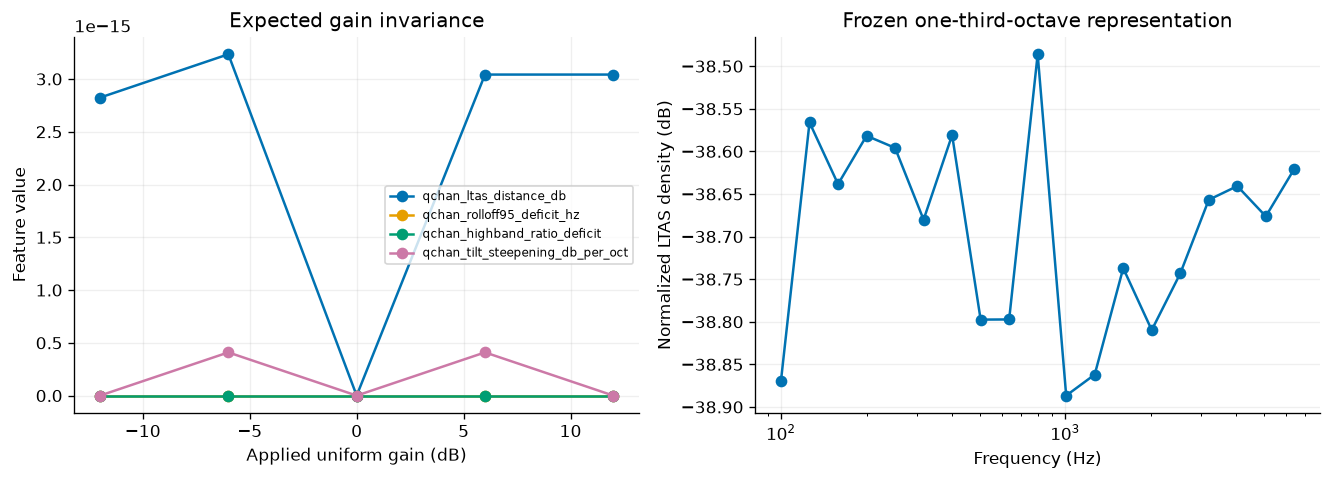

,layer,check,passed,observed,required,action_if_failed,blocking
0,formula,uniform gain invariance,True,9.09e-13,<1e-8 maximum feature value,repair level anchoring,True
1,formula,polarity invariance,True,9.22e-19,<1e-12 PSD difference,repair spectral estimator,True
2,formula,identity condition returns exact zero,True,checked,all four <1e-12,repair formulas,True


In [3]:
def spectrum_for_signal(y, recording_id, *, parameters=PARAMETERS, source_rate=48_000):
    return extract_recording_spectrum(
        y, parameters.analysis_sample_rate_hz,
        strict_speech=full_span_interval(y, parameters.analysis_sample_rate_hz),
        logical_recording_id=recording_id,
        source_sample_rate_hz=source_rate,
        parameters=parameters,
    )


def direct_reference(recording_spectrum, *, key="validation_reference"):
    return ReferenceSpectrum(
        reference_key=key,
        task_stratum="synthetic_validation",
        excluded_subject_id="synthetic_target",
        frequencies_hz=recording_spectrum.frequencies_hz,
        normalized_psd_per_hz=recording_spectrum.normalized_psd_per_hz,
        status="measured",
        member_recording_ids=("synthetic_reference",),
        member_subject_ids=("synthetic_reference_subject",),
        recording_count=1,
        subject_count=1,
        reference_sha256=recording_spectrum.spectrum_sha256,
        reference_vintage_sha256="synthetic_vintage",
    )


formula_rows = []
maximum_spectrum_difference = 0.0
for seed in range(PARAMETERS.random_seed, PARAMETERS.random_seed + 6):
    baseline = synthetic_speech_like(seed=seed)
    baseline_spectrum = spectrum_for_signal(baseline, f"baseline_{seed}")
    reference = direct_reference(baseline_spectrum)
    for gain_db in [-12.0, -6.0, 0.0, 6.0, 12.0]:
        changed = spectrum_for_signal(
            apply_gain_db(baseline, gain_db), f"gain_{seed}_{gain_db}"
        )
        maximum_spectrum_difference = max(
            maximum_spectrum_difference,
            float(np.max(np.abs(
                changed.normalized_psd_per_hz
                - baseline_spectrum.normalized_psd_per_hz
            ))),
        )
        result = compute_reference_relative_features(changed, reference)
        formula_rows.append({"seed": seed, "gain_db": gain_db, **{
            feature: result[feature] for feature in ANALYSIS_FEATURES
        }})
    inverted = spectrum_for_signal(-baseline, f"polarity_{seed}")
    maximum_spectrum_difference = max(
        maximum_spectrum_difference,
        float(np.max(np.abs(
            inverted.normalized_psd_per_hz
            - baseline_spectrum.normalized_psd_per_hz
        ))),
    )

formula_validation = pd.DataFrame(formula_rows)
save_table_bundle(
    formula_validation, TABLES, "qchan_v301_formula_transform_validation"
)
formula_checks = validation_frame([
    ValidationCheck(
        "formula", "uniform gain invariance",
        formula_validation[list(ANALYSIS_FEATURES)].abs().to_numpy().max() < 1e-8,
        f"{formula_validation[list(ANALYSIS_FEATURES)].abs().to_numpy().max():.3g}",
        "<1e-8 maximum feature value", "repair level anchoring",
    ),
    ValidationCheck(
        "formula", "polarity invariance",
        maximum_spectrum_difference < 1e-12,
        f"{maximum_spectrum_difference:.3g}", "<1e-12 PSD difference",
        "repair spectral estimator",
    ),
    ValidationCheck(
        "formula", "identity condition returns exact zero",
        bool((formula_validation.loc[
            formula_validation["gain_db"].eq(0), list(ANALYSIS_FEATURES)
        ].abs() < 1e-12).all().all()),
        "checked", "all four <1e-12", "repair formulas",
    ),
])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1))
for feature, color in zip(
    ANALYSIS_FEATURES,
    [OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["green"], OKABE_ITO["purple"]],
):
    summary = formula_validation.groupby("gain_db")[feature].median()
    axes[0].plot(summary.index, summary.values, "o-", label=feature, color=color)
axes[0].set(
    xlabel="Applied uniform gain (dB)", ylabel="Feature value",
    title="Expected gain invariance",
)
axes[0].legend(fontsize=7)
base = synthetic_speech_like()
base_spectrum = spectrum_for_signal(base, "formula_display")
centers, levels = smoothed_log_ltas_db(
    base_spectrum.frequencies_hz, base_spectrum.normalized_psd_per_hz
)
axes[1].semilogx(centers, levels, "o-", color=OKABE_ITO["blue"])
axes[1].set(
    xlabel="Frequency (Hz)", ylabel="Normalized LTAS density (dB)",
    title="Frozen one-third-octave representation",
)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qchan_formula_transform_validation",
    caption="QCHAN formula validation: uniform gain and polarity do not change the gain-normalized estimators.",
    alt_text="Feature values remain at numerical zero over applied gains; the second panel shows the one-third-octave LTAS representation.",
)
plt.show()
display(formula_checks)

## 3. Synthetic construct validity and discriminant controls

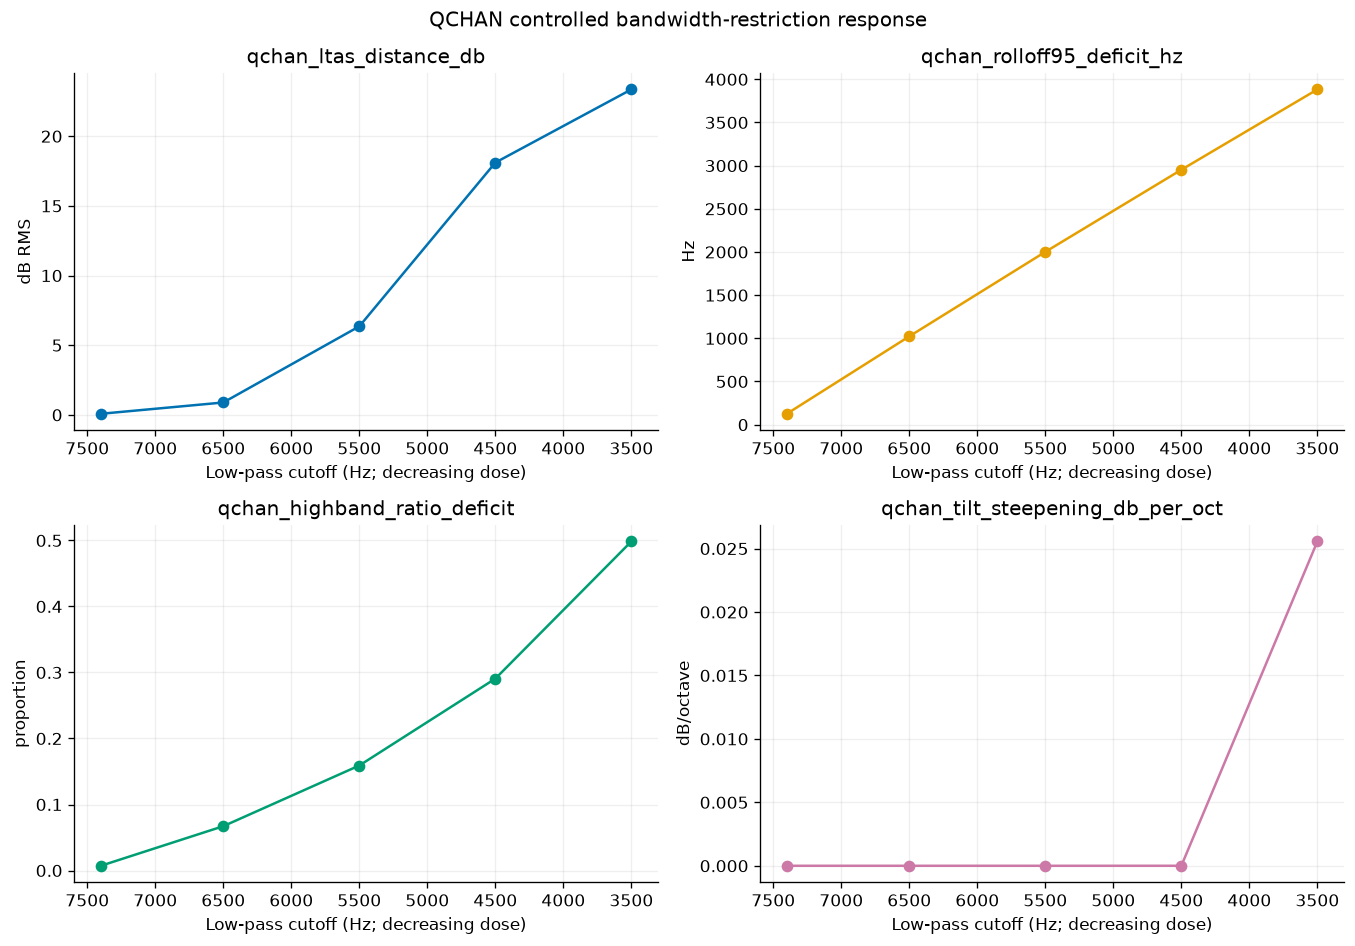

,layer,check,passed,observed,required,action_if_failed,blocking
0,construct,lowpass ltas monotonic,True,100% seeds,100% deterministic seeds,repair estimator or claim,True
1,construct,lowpass rolloff monotonic,True,100% seeds,100% deterministic seeds,repair estimator or claim,True
2,construct,lowpass highband monotonic,True,100% seeds,100% deterministic seeds,repair estimator or claim,True
3,construct,shelf tilt monotonic,True,100% seeds,100% deterministic seeds,repair estimator or claim,True
4,construct,positive shelf is nonordinal only,True,100% seeds,100% deterministic seeds,repair estimator or claim,True
5,construct,notch detected by ltas,True,100% seeds,100% deterministic seeds,repair estimator or claim,True


In [4]:
construct_rows = []
lowpass_cutoffs = [7400.0, 6500.0, 5500.0, 4500.0, 3500.0]
shelf_gains = [12.0, 6.0, 0.0, -6.0, -12.0, -18.0]
for seed in range(PARAMETERS.random_seed, PARAMETERS.random_seed + 8):
    baseline = synthetic_speech_like(seed=seed)
    baseline_spectrum = spectrum_for_signal(baseline, f"construct_base_{seed}")
    reference = direct_reference(baseline_spectrum, key=f"construct_{seed}")
    for cutoff in lowpass_cutoffs:
        observed = spectrum_for_signal(
            lowpass_filter(baseline, FS, cutoff), f"lp_{seed}_{cutoff}"
        )
        result = compute_reference_relative_features(observed, reference)
        construct_rows.append({
            "seed": seed, "perturbation": "lowpass",
            "dose": cutoff, **{f: result[f] for f in ANALYSIS_FEATURES},
        })
    for gain in shelf_gains:
        observed = spectrum_for_signal(
            smooth_high_shelf(baseline, FS, gain, transition_hz=1500),
            f"shelf_{seed}_{gain}",
        )
        result = compute_reference_relative_features(observed, reference)
        construct_rows.append({
            "seed": seed, "perturbation": "high_shelf",
            "dose": gain, **{f: result[f] for f in ANALYSIS_FEATURES},
        })
    notched = spectrum_for_signal(
        broad_notch_filter(baseline, FS), f"notch_{seed}"
    )
    result = compute_reference_relative_features(notched, reference)
    construct_rows.append({
        "seed": seed, "perturbation": "broad_notch",
        "dose": -18.0, **{f: result[f] for f in ANALYSIS_FEATURES},
    })

construct_validation = pd.DataFrame(construct_rows)
save_table_bundle(
    construct_validation, TABLES, "qchan_v301_synthetic_construct_validity"
)

seed_checks = []
for seed, local in construct_validation.groupby("seed"):
    lowpass_local = local.loc[local["perturbation"].eq("lowpass")].sort_values(
        "dose", ascending=False
    )
    shelf_local = local.loc[local["perturbation"].eq("high_shelf")].sort_values(
        "dose", ascending=False
    )
    seed_checks.append({
        "seed": seed,
        "lowpass_ltas_monotonic": bool(np.all(np.diff(
            lowpass_local["qchan_ltas_distance_db"]
        ) >= -1e-8)),
        "lowpass_rolloff_monotonic": bool(np.all(np.diff(
            lowpass_local["qchan_rolloff95_deficit_hz"]
        ) >= -1e-8)),
        "lowpass_highband_monotonic": bool(np.all(np.diff(
            lowpass_local["qchan_highband_ratio_deficit"]
        ) >= -1e-8)),
        "shelf_tilt_monotonic": bool(np.all(np.diff(
            shelf_local["qchan_tilt_steepening_db_per_oct"]
        ) >= -1e-8)),
        "positive_shelf_is_nonordinal_only": bool(
            shelf_local.iloc[0]["qchan_ltas_distance_db"] > 0.5
            and shelf_local.iloc[0]["qchan_rolloff95_deficit_hz"] < 1e-8
            and shelf_local.iloc[0]["qchan_highband_ratio_deficit"] < 1e-8
            and shelf_local.iloc[0]["qchan_tilt_steepening_db_per_oct"] < 1e-8
        ),
        "notch_detected_by_ltas": bool(
            local.loc[
                local["perturbation"].eq("broad_notch"),
                "qchan_ltas_distance_db",
            ].iloc[0] > 0.5
        ),
    })
construct_seed_checks = pd.DataFrame(seed_checks)
construct_checks = validation_frame([
    ValidationCheck(
        "construct", column.replace("_", " "),
        bool(construct_seed_checks[column].all()),
        f"{construct_seed_checks[column].mean():.0%} seeds",
        "100% deterministic seeds", "repair estimator or claim",
    )
    for column in construct_seed_checks.columns if column != "seed"
])
save_table_bundle(
    construct_seed_checks, AUDIT, "qchan_v301_construct_seed_checks"
)

fig, axes = plt.subplots(2, 2, figsize=(11.4, 8.0))
lowpass_summary = (
    construct_validation.loc[
        construct_validation["perturbation"].eq("lowpass")
    ]
    .groupby("dose")[list(ANALYSIS_FEATURES)].median()
    .sort_index(ascending=False)
)
shelf_summary = (
    construct_validation.loc[
        construct_validation["perturbation"].eq("high_shelf")
    ]
    .groupby("dose")[list(ANALYSIS_FEATURES)].median()
    .sort_index(ascending=False)
)
for ax, feature, color in zip(
    axes.flat,
    ANALYSIS_FEATURES,
    [OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["green"], OKABE_ITO["purple"]],
):
    ax.plot(lowpass_summary.index, lowpass_summary[feature], "o-", color=color, label="low-pass")
    ax.set_title(feature)
    ax.set_xlabel("Low-pass cutoff (Hz; decreasing dose)")
    ax.set_ylabel(FEATURE_DEFINITIONS[feature]["unit"])
    ax.invert_xaxis()
fig.suptitle("QCHAN controlled bandwidth-restriction response")
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qchan_synthetic_construct_validity",
    caption="Controlled low-pass filtering produces the prespecified response of the QCHAN profile across eight deterministic speech-like realizations.",
    alt_text="Four dose-response plots for LTAS distance, rolloff deficit, high-band deficit, and tilt steepening as low-pass cutoff decreases.",
)
plt.show()
display(construct_checks)

In [5]:
discriminant_rows = []
for seed in range(PARAMETERS.random_seed, PARAMETERS.random_seed + 8):
    baseline = synthetic_speech_like(seed=seed)
    baseline_spectrum = spectrum_for_signal(baseline, f"disc_base_{seed}")
    reference = direct_reference(baseline_spectrum, key=f"disc_{seed}")
    rng = np.random.default_rng(seed + 10_000)
    noise = rng.normal(size=len(baseline))
    noise = signal.sosfilt(
        signal.butter(4, 3500/(FS/2), btype="high", output="sos"), noise
    )
    noise = noise / max(np.std(noise), np.finfo(float).tiny)
    noisy = baseline + 0.03 * noise
    rir = np.zeros(int(0.35 * FS))
    rir[0] = 1.0
    rir[1:] = 0.12 * np.exp(-np.arange(1, len(rir)) / (0.08 * FS))
    reverberant = signal.fftconvolve(baseline, rir, mode="full")[:len(baseline)]
    common_filtered = lowpass_filter(baseline, FS, 4000)
    conditions = {
        "identity": baseline,
        "high_frequency_additive_noise": noisy,
        "reverberation_like_smearing": reverberant,
        "common_mode_lowpass": common_filtered,
    }
    for condition, waveform in conditions.items():
        observed = spectrum_for_signal(waveform, f"{condition}_{seed}")
        local_reference = (
            direct_reference(observed, key=f"common_mode_{seed}")
            if condition == "common_mode_lowpass" else reference
        )
        result = compute_reference_relative_features(observed, local_reference)
        discriminant_rows.append({
            "seed": seed, "condition": condition,
            **{feature: result[feature] for feature in ANALYSIS_FEATURES},
        })

discriminant_validation = pd.DataFrame(discriminant_rows)
save_table_bundle(
    discriminant_validation, TABLES, "qchan_v301_discriminant_controls"
)
common_mode_max = discriminant_validation.loc[
    discriminant_validation["condition"].eq("common_mode_lowpass"),
    list(ANALYSIS_FEATURES),
].abs().to_numpy().max()
discriminant_checks = validation_frame([
    ValidationCheck(
        "discriminant", "cohort-common effect is not a relative abnormality",
        common_mode_max < 1e-10,
        f"{common_mode_max:.3g}", "<1e-10 under matched target/reference filtering",
        "repair reference-relative formulas",
    ),
    ValidationCheck(
        "discriminant", "noise and reverberation sensitivities are characterized",
        {"high_frequency_additive_noise", "reverberation_like_smearing"}.issubset(
            set(discriminant_validation["condition"])
        ),
        "present", "both present", "restore cross-family controls",
    ),
])
display(
    discriminant_validation.groupby("condition")[
        list(ANALYSIS_FEATURES)
    ].median()
)
display(discriminant_checks)

,qchan_ltas_distance_db,qchan_rolloff95_deficit_hz,qchan_highband_ratio_deficit,qchan_tilt_steepening_db_per_oct
condition,,,,
common_mode_lowpass,0.000000,0.000000,0.000000,0.000000
high_frequency_additive_noise,1.332838,0.000000,0.000000,0.000000
identity,0.000000,0.000000,0.000000,0.000000
reverberation_like_smearing,3.712898,49.616844,0.071702,1.863272


,layer,check,passed,observed,required,action_if_failed,blocking
0,discriminant,cohort-common effect is not a relative abnorma...,True,0,<1e-10 under matched target/reference filtering,repair reference-relative formulas,True
1,discriminant,noise and reverberation sensitivities are char...,True,present,both present,restore cross-family controls,True


## 4. Source-bandwidth, spectral-floor, and codec characterization

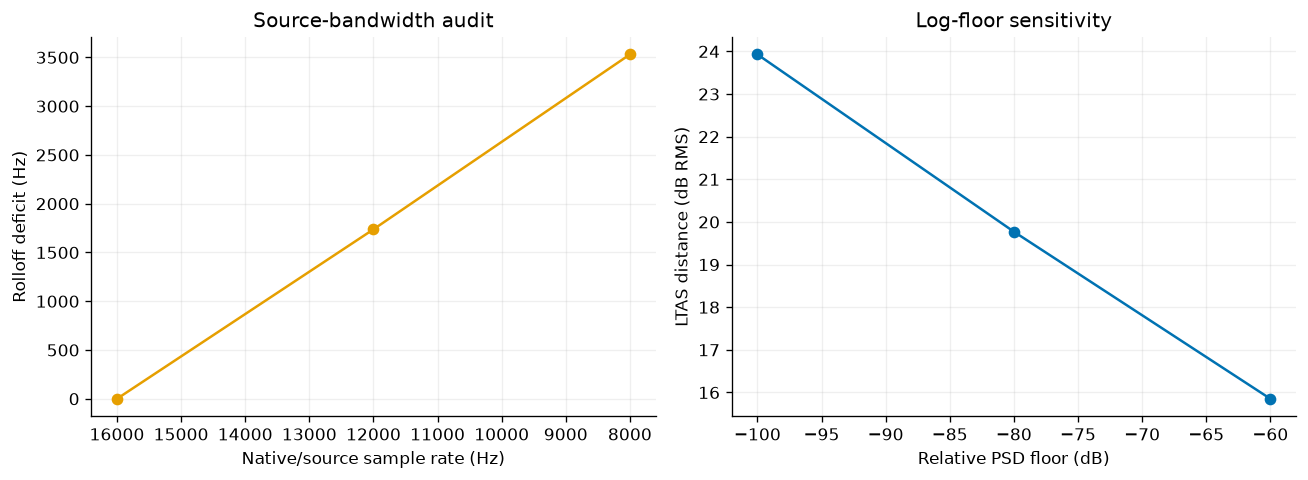

,layer,check,passed,observed,required,action_if_failed,blocking
0,bandwidth,source Nyquist limitation is explicitly flagged,True,checked,all <15-kHz sources flagged,repair native-bandwidth audit,True
1,bandwidth,lower source rate increases bandwidth deficits,True,dose ordered,monotonic,repair source-bandwidth handling,True
2,floor,feature rankings are stable over floor sensiti...,True,minimum rho=0.943,pairwise rho >=0.90; absolute scale dependence...,revise floor or qualify estimator,True
3,codec,lossless PCM roundtrip stability,True,7.632e-06,maximum change <0.05 in native feature units,inspect serialization or estimator,True


In [6]:
bandwidth_rows = []
floor_rows = []
lossless_rows = []
for seed in range(PARAMETERS.random_seed, PARAMETERS.random_seed + 6):
    baseline = synthetic_speech_like(seed=seed)
    baseline_spectrum = spectrum_for_signal(baseline, f"band_base_{seed}")
    reference = direct_reference(baseline_spectrum, key=f"band_{seed}")
    for intermediate_rate in [16_000, 12_000, 8_000]:
        if intermediate_rate == FS:
            restored = baseline.copy()
        else:
            down = signal.resample_poly(baseline, intermediate_rate, FS)
            restored = signal.resample_poly(down, FS, intermediate_rate)
            restored = restored[:len(baseline)]
        observed = spectrum_for_signal(
            restored, f"source_{seed}_{intermediate_rate}",
            source_rate=intermediate_rate,
        )
        result = compute_reference_relative_features(observed, reference)
        bandwidth_rows.append({
            "seed": seed, "source_sample_rate_hz": intermediate_rate,
            "source_nyquist_hz": intermediate_rate / 2,
            "source_bandwidth_limited": observed.source_bandwidth_limited,
            **{feature: result[feature] for feature in ANALYSIS_FEATURES},
        })
    for floor_db in [-60.0, -80.0, -100.0]:
        local_parameters = replace(PARAMETERS, relative_psd_floor_db=floor_db)
        observed = spectrum_for_signal(
            lowpass_filter(baseline, FS, 4000),
            f"floor_{seed}_{floor_db}",
            parameters=local_parameters,
        )
        local_reference_spectrum = spectrum_for_signal(
            baseline, f"floor_ref_{seed}_{floor_db}",
            parameters=local_parameters,
        )
        result = compute_reference_relative_features(
            observed,
            direct_reference(local_reference_spectrum, key=f"floor_{seed}"),
            parameters=local_parameters,
        )
        floor_rows.append({
            "seed": seed, "relative_psd_floor_db": floor_db,
            **{feature: result[feature] for feature in ANALYSIS_FEATURES},
        })
    with TemporaryDirectory() as temporary_directory:
        wav_path = Path(temporary_directory) / "fixture.wav"
        sf.write(wav_path, baseline, FS, subtype="PCM_24")
        decoded, decoded_rate = sf.read(wav_path, dtype="float64")
        decoded_spectrum = spectrum_for_signal(
            decoded, f"lossless_{seed}", source_rate=decoded_rate
        )
        result = compute_reference_relative_features(decoded_spectrum, reference)
        lossless_rows.append({
            "seed": seed,
            **{feature: result[feature] for feature in ANALYSIS_FEATURES},
        })

source_bandwidth_validation = pd.DataFrame(bandwidth_rows)
floor_validation = pd.DataFrame(floor_rows)
lossless_validation = pd.DataFrame(lossless_rows)
save_table_bundle(
    source_bandwidth_validation, TABLES, "qchan_v301_source_bandwidth_validation"
)
save_table_bundle(
    floor_validation, TABLES, "qchan_v301_spectral_floor_validation"
)
save_table_bundle(
    lossless_validation, TABLES, "qchan_v301_lossless_roundtrip_validation"
)

floor_ranks_ok = True
floor_rank_minimum = 1.0
floor_scale_rows = []
for feature in ANALYSIS_FEATURES:
    pivot = floor_validation.pivot(
        index="seed", columns="relative_psd_floor_db", values=feature
    )
    correlations = pivot.corr(method="spearman").to_numpy()
    finite_correlations = correlations[np.isfinite(correlations)]
    local_minimum = (
        float(np.min(finite_correlations))
        if finite_correlations.size else np.nan
    )
    floor_rank_minimum = min(floor_rank_minimum, local_minimum)
    floor_ranks_ok &= bool(local_minimum >= 0.90)
    floor_scale_rows.append({
        "feature": feature,
        "minimum_pairwise_spearman": local_minimum,
        "median_within_seed_range": float(
            (pivot.max(axis=1) - pivot.min(axis=1)).median()
        ),
        "maximum_within_seed_range": float(
            (pivot.max(axis=1) - pivot.min(axis=1)).max()
        ),
        "interpretation": (
            "Ranking stability is required. Absolute LTAS-distance "
            "magnitude is expected to depend on the frozen dB floor "
            "under near-zero high-band power."
        ),
    })
floor_scale_sensitivity = pd.DataFrame(floor_scale_rows)
save_table_bundle(
    floor_scale_sensitivity, TABLES,
    "qchan_v301_spectral_floor_scale_sensitivity",
)
source_checks = validation_frame([
    ValidationCheck(
        "bandwidth", "source Nyquist limitation is explicitly flagged",
        bool(source_bandwidth_validation.loc[
            source_bandwidth_validation["source_sample_rate_hz"].lt(15_000),
            "source_bandwidth_limited",
        ].all()),
        "checked", "all <15-kHz sources flagged", "repair native-bandwidth audit",
    ),
    ValidationCheck(
        "bandwidth", "lower source rate increases bandwidth deficits",
        bool(
            source_bandwidth_validation.groupby("source_sample_rate_hz")[
                "qchan_rolloff95_deficit_hz"
            ].median().sort_index(ascending=False).is_monotonic_increasing
            and source_bandwidth_validation.groupby("source_sample_rate_hz")[
                "qchan_highband_ratio_deficit"
            ].median().sort_index(ascending=False).is_monotonic_increasing
        ),
        "dose ordered", "monotonic", "repair source-bandwidth handling",
    ),
    ValidationCheck(
        "floor", "feature rankings are stable over floor sensitivity",
        floor_ranks_ok, f"minimum rho={floor_rank_minimum:.3f}",
        "pairwise rho >=0.90; absolute scale dependence reported",
        "revise floor or qualify estimator",
    ),
    ValidationCheck(
        "codec", "lossless PCM roundtrip stability",
        lossless_validation[list(ANALYSIS_FEATURES)].abs().to_numpy().max() < 0.05,
        f"{lossless_validation[list(ANALYSIS_FEATURES)].abs().to_numpy().max():.4g}",
        "maximum change <0.05 in native feature units",
        "inspect serialization or estimator",
    ),
])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1))
summary = source_bandwidth_validation.groupby(
    "source_sample_rate_hz"
)[list(ANALYSIS_FEATURES)].median().sort_index(ascending=False)
axes[0].plot(
    summary.index, summary["qchan_rolloff95_deficit_hz"],
    "o-", color=OKABE_ITO["orange"], label="rolloff deficit (Hz)",
)
axes[0].invert_xaxis()
axes[0].set(
    xlabel="Native/source sample rate (Hz)",
    ylabel="Rolloff deficit (Hz)",
    title="Source-bandwidth audit",
)
floor_summary = floor_validation.groupby(
    "relative_psd_floor_db"
)["qchan_ltas_distance_db"].median()
axes[1].plot(
    floor_summary.index, floor_summary.values,
    "o-", color=OKABE_ITO["blue"],
)
axes[1].set(
    xlabel="Relative PSD floor (dB)",
    ylabel="LTAS distance (dB RMS)",
    title="Log-floor sensitivity",
)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qchan_bandwidth_floor_calibration",
    caption="QCHAN source-bandwidth and logarithmic-floor calibration.",
    alt_text="Rolloff deficit increases as source sample rate decreases; LTAS-distance ranking remains stable while absolute magnitude changes with the frozen logarithmic floor under near-zero spectral power.",
)
plt.show()
display(source_checks)

## 5. Frozen input and provenance contract

In [7]:
def _table_file(stem: Path) -> Path:
    if stem.suffix.lower() in {".csv", ".parquet"} and stem.exists():
        return stem
    for suffix in [".parquet", ".csv"]:
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Missing frozen table: {stem}")


def read_table(stem: Path) -> pd.DataFrame:
    path = _table_file(stem)
    return (
        pd.read_parquet(path, engine=PARQUET_ENGINE)
        if path.suffix.lower() == ".parquet"
        else pd.read_csv(path)
    )


def as_bool(series: pd.Series) -> pd.Series:
    true_values = {"1", "true", "yes", "y"}
    false_values = {"0", "false", "no", "n", ""}

    def convert(value):
        if isinstance(value, (bool, np.bool_)):
            return bool(value)
        if pd.isna(value):
            return False
        token = str(value).strip().lower()
        if token in true_values:
            return True
        if token in false_values:
            return False
        raise ValueError(f"Unrecognized boolean token: {value!r}")

    return series.map(convert).astype(bool)


def normalize_text(series: pd.Series) -> pd.Series:
    normalized = series.astype("string").str.strip()
    return normalized.mask(normalized.eq(""), pd.NA)


def resolve_equivalent_column(
    frame: pd.DataFrame,
    candidates: list[str],
    field: str,
    *,
    required: bool = True,
) -> tuple[str | None, list[str]]:
    present = [column for column in candidates if column in frame.columns]
    if not present:
        if required:
            raise ValueError(
                f"Frozen inputs lack {field}; accepted columns={candidates}; "
                f"available columns={list(frame.columns)}"
            )
        return None, []

    canonical = present[0]
    canonical_values = normalize_text(frame[canonical])
    for column in present[1:]:
        other = normalize_text(frame[column])
        comparable = canonical_values.notna() & other.notna()
        disagreement = comparable & ~canonical_values.eq(other)
        if disagreement.any():
            examples = frame.loc[
                disagreement, [canonical, column]
            ].head(10).to_dict(orient="records")
            raise ValueError(
                f"Conflicting frozen columns for {field}: "
                f"{canonical} vs {column}; examples={examples}"
            )
    return canonical, present


def resolved_media_path(value) -> Path:
    path = Path(str(value))
    return path if path.is_absolute() else ROOT / path


def load_frozen_inputs() -> dict:
    cfg = yaml.safe_load(CONFIG.read_text(encoding="utf-8"))
    data_version = DATA_FREEZE_VERSION
    segmentation_version = SEGMENTATION_FREEZE_VERSION
    data_version_source = "notebook_constant:DATA_FREEZE_VERSION"
    segmentation_version_source = (
        "notebook_constant:SEGMENTATION_FREEZE_VERSION"
    )

    configured_data_version = cfg.get("data_freeze", {}).get("version")
    configured_segmentation_version = cfg.get(
        "segmentation_freeze", {}
    ).get("version")
    if (
        configured_data_version is not None
        and str(configured_data_version).strip() != data_version
    ):
        raise ValueError(
            "project.yaml data_freeze.version disagrees with the pinned "
            f"QCHAN version: config={configured_data_version!r}, "
            f"notebook={data_version!r}"
        )
    if (
        configured_segmentation_version is not None
        and str(configured_segmentation_version).strip()
        != segmentation_version
    ):
        raise ValueError(
            "project.yaml segmentation_freeze.version disagrees with the "
            f"pinned QCHAN version: config={configured_segmentation_version!r}, "
            f"notebook={segmentation_version!r}"
        )
    data_folder = MAIN_OUTPUTS / "00_DATA_FREEZE" / data_version
    segmentation_folder = (
        MAIN_OUTPUTS / "01_SEGMENTATION_FREEZE" / segmentation_version
    )

    recordings_path = _table_file(
        data_folder / "frozen_bamboo_recordings"
    )
    decisions_path = _table_file(
        segmentation_folder / "frozen_segmentation_decisions"
    )
    # The upstream freeze contract names this artifact explicitly. Do not
    # heuristically select another table from the folder.
    intervals_path = _table_file(
        segmentation_folder / "frozen_segmentation_intervals"
    )

    recordings = read_table(recordings_path)
    decisions = read_table(decisions_path)
    intervals = read_table(intervals_path)

    for artifact, frame in [
        ("frozen recordings", recordings),
        ("frozen decisions", decisions),
    ]:
        if "logical_recording_id" not in frame.columns:
            raise ValueError(f"{artifact} lacks logical_recording_id")
        frame["logical_recording_id"] = normalize_text(
            frame["logical_recording_id"]
        )
        if frame["logical_recording_id"].isna().any():
            raise ValueError(f"{artifact} contains missing/blank recording IDs")

    if "segmentation_analysis_eligible" not in decisions.columns:
        raise ValueError(
            "Frozen decisions lack segmentation_analysis_eligible"
        )
    eligible = decisions.loc[
        as_bool(decisions["segmentation_analysis_eligible"])
    ].copy()
    if eligible["logical_recording_id"].duplicated().any():
        duplicates = sorted(
            eligible.loc[
                eligible["logical_recording_id"].duplicated(keep=False),
                "logical_recording_id",
            ].astype(str).unique()
        )
        raise ValueError(
            f"Frozen decisions contain duplicate eligible IDs: {duplicates[:20]}"
        )

    if "logical_recording_id" not in intervals.columns:
        if "file_name" not in intervals.columns or "file_name" not in decisions.columns:
            raise ValueError(
                "Frozen intervals require logical_recording_id, or a file_name "
                "that can be mapped through frozen decisions."
            )
        mapping = decisions[["file_name", "logical_recording_id"]].copy()
        mapping["file_name"] = normalize_text(mapping["file_name"])
        mapping = mapping.drop_duplicates()
        if mapping["file_name"].isna().any() or mapping["file_name"].duplicated().any():
            raise ValueError(
                "file_name is missing or non-unique in frozen decisions; "
                "interval identity is ambiguous."
            )
        intervals["file_name"] = normalize_text(intervals["file_name"])
        intervals = intervals.merge(
            mapping,
            on="file_name",
            how="left",
            validate="many_to_one",
        )
    intervals["logical_recording_id"] = normalize_text(
        intervals["logical_recording_id"]
    )
    if intervals["logical_recording_id"].isna().any():
        raise ValueError("Frozen intervals contain unmapped recording IDs")

    media_column, media_aliases = resolve_equivalent_column(
        recordings,
        ["media_path", "selected_media_path", "file_path", "selected_path"],
        "selected media path",
    )
    subject_column, subject_aliases = resolve_equivalent_column(
        recordings,
        ["SubjectID", "subject_id", "participant_id", "subject_uid", "participant_uid"],
        "subject identity",
        required=False,
    )
    decision_subject_column, decision_subject_aliases = resolve_equivalent_column(
        eligible,
        ["SubjectID", "subject_id", "participant_id", "subject_uid", "participant_uid"],
        "subject identity in frozen decisions",
        required=False,
    )
    if subject_column is None and decision_subject_column is None:
        raise ValueError(
            "Neither frozen recordings nor frozen decisions contains subject identity."
        )

    recording_identity = recordings[["logical_recording_id"]].copy()
    recording_identity["media_path"] = normalize_text(recordings[media_column])
    if subject_column is not None:
        recording_identity["subject_id"] = normalize_text(
            recordings[subject_column]
        )

    file_name_column, file_name_aliases = resolve_equivalent_column(
        recordings,
        ["file_name", "Raw Media File name", "selected_media_file_name"],
        "recording file name",
        required=False,
    )
    if file_name_column is not None:
        recording_identity["file_name"] = normalize_text(
            recordings[file_name_column]
        )
    else:
        recording_identity["file_name"] = recording_identity[
            "media_path"
        ].map(lambda value: Path(str(value)).name if pd.notna(value) else pd.NA)

    if decision_subject_column is not None:
        decision_identity = eligible[
            ["logical_recording_id", decision_subject_column]
        ].copy()
        decision_identity["subject_id_decisions"] = normalize_text(
            decision_identity[decision_subject_column]
        )
        decision_identity = decision_identity[
            ["logical_recording_id", "subject_id_decisions"]
        ]
        if decision_identity["logical_recording_id"].duplicated().any():
            raise ValueError(
                "Frozen decisions contain conflicting subject identity."
            )
        recording_identity = recording_identity.merge(
            decision_identity,
            on="logical_recording_id",
            how="left",
            validate="one_to_one",
        )
        if "subject_id" not in recording_identity.columns:
            recording_identity["subject_id"] = recording_identity[
                "subject_id_decisions"
            ]
        else:
            comparable = (
                recording_identity["subject_id"].notna()
                & recording_identity["subject_id_decisions"].notna()
            )
            disagreement = comparable & ~recording_identity[
                "subject_id"
            ].eq(recording_identity["subject_id_decisions"])
            if disagreement.any():
                examples = recording_identity.loc[
                    disagreement,
                    ["logical_recording_id", "subject_id", "subject_id_decisions"],
                ].head(10).to_dict(orient="records")
                raise ValueError(
                    "Subject identity disagrees between frozen recordings and "
                    f"frozen decisions: {examples}"
                )
            recording_identity["subject_id"] = recording_identity[
                "subject_id"
            ].fillna(recording_identity["subject_id_decisions"])
    else:
        recording_identity["subject_id_decisions"] = pd.NA

    task_column, task_aliases = resolve_equivalent_column(
        recordings,
        ["task_stratum", "task_name", "task", "protocol_task"],
        "task stratum",
        required=False,
    )
    if task_column is None:
        default_task = str(
            cfg.get("cohort", {}).get("primary_task", "Bamboo passage")
        ).strip()
        if not default_task:
            raise ValueError("No task column and cohort.primary_task is blank")
        recording_identity["task_stratum"] = default_task
        task_source = "config:cohort.primary_task"
    else:
        recording_identity["task_stratum"] = normalize_text(
            recordings[task_column]
        )
        task_source = f"frozen_recordings:{task_column}"

    if recording_identity["logical_recording_id"].duplicated().any():
        duplicates = sorted(
            recording_identity.loc[
                recording_identity["logical_recording_id"].duplicated(keep=False),
                "logical_recording_id",
            ].astype(str).unique()
        )
        raise ValueError(
            f"Frozen recording table contains duplicate logical IDs: {duplicates[:20]}"
        )

    analysis_recordings = eligible[["logical_recording_id"]].merge(
        recording_identity[
            [
                "logical_recording_id",
                "subject_id",
                "task_stratum",
                "media_path",
                "file_name",
            ]
        ],
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )
    for column in ["subject_id", "task_stratum", "media_path", "file_name"]:
        analysis_recordings[column] = normalize_text(
            analysis_recordings[column]
        )

    intervals = intervals.rename(
        columns={"start": "start_sec", "end": "end_sec"}
    )
    if not {"start_sec", "end_sec"}.issubset(intervals.columns):
        raise ValueError("Frozen intervals lack start_sec/end_sec")
    intervals["start_sec"] = pd.to_numeric(
        intervals["start_sec"], errors="coerce"
    )
    intervals["end_sec"] = pd.to_numeric(
        intervals["end_sec"], errors="coerce"
    )
    view_column, view_aliases = resolve_equivalent_column(
        intervals,
        ["view", "segment_type", "label", "region"],
        "interval view",
    )
    intervals["view"] = (
        normalize_text(intervals[view_column])
        .str.lower()
        .str.replace(r"[\s\-]+", "_", regex=True)
    )
    if "profile" in intervals.columns:
        profile = (
            normalize_text(intervals["profile"])
            .str.lower()
            .str.replace(r"[\s\-]+", "_", regex=True)
        )
        if profile.eq("primary").any():
            intervals = intervals.loc[profile.eq("primary")].copy()

    eligible_ids = set(analysis_recordings["logical_recording_id"].dropna())
    intervals = intervals.loc[
        intervals["logical_recording_id"].isin(eligible_ids)
    ].copy()
    available_views = sorted(
        intervals["view"].dropna().astype(str).unique()
    )
    strict_view = next(
        (
            name
            for name in [
                "strict_speech",
                "primary_speech",
                "final_speech",
                "speech",
            ]
            if name in available_views
        ),
        None,
    )

    strict_intervals = (
        intervals.loc[intervals["view"].eq(strict_view)].copy()
        if strict_view is not None
        else intervals.iloc[0:0].copy()
    )
    interval_boundary_valid = bool(
        len(strict_intervals)
        and strict_intervals[["start_sec", "end_sec"]].notna().all().all()
        and np.isfinite(
            strict_intervals[["start_sec", "end_sec"]].to_numpy(float)
        ).all()
        and strict_intervals["start_sec"].ge(0).all()
        and strict_intervals["end_sec"].gt(
            strict_intervals["start_sec"]
        ).all()
    )
    strict_ids = set(strict_intervals["logical_recording_id"].dropna())
    missing_strict_ids = sorted(eligible_ids - strict_ids)
    media_exists = analysis_recordings["media_path"].map(
        lambda value: pd.notna(value) and resolved_media_path(value).is_file()
    )

    reference_metadata = analysis_recordings[
        ["logical_recording_id", "subject_id", "task_stratum"]
    ].copy()
    exact_reference_schema = list(reference_metadata.columns) == [
        "logical_recording_id",
        "subject_id",
        "task_stratum",
    ]
    prohibited_reference_field_tokens = (
        "diagnosis", "alsfrs", "severity", "clinical", "human_qc", "rater",
    )
    prohibited_reference_columns = [
        column
        for column in reference_metadata.columns
        if any(
            token in str(column).lower()
            for token in prohibited_reference_field_tokens
        )
    ]
    reference_schema_is_label_blind = bool(
        exact_reference_schema and not prohibited_reference_columns
    )

    explicit_versions = bool(
        data_version == DATA_FREEZE_VERSION
        and segmentation_version == SEGMENTATION_FREEZE_VERSION
        and data_version_source.startswith("notebook_constant")
        and segmentation_version_source.startswith("notebook_constant")
    )
    checks = validation_frame([
        ValidationCheck(
            "input",
            "authoritative frozen artifacts selected explicitly",
            all(path.exists() for path in [recordings_path, decisions_path, intervals_path]),
            str([recordings_path.name, decisions_path.name, intervals_path.name]),
            "frozen_bamboo_recordings, frozen_segmentation_decisions, frozen_segmentation_intervals",
            "repair upstream freeze",
        ),
        ValidationCheck(
            "input",
            "one eligible row per recording",
            not analysis_recordings["logical_recording_id"].duplicated().any(),
            str(len(analysis_recordings)),
            "unique logical_recording_id",
            "repair segmentation freeze",
        ),
        ValidationCheck(
            "input",
            "complete subject, task, path, and file identity",
            analysis_recordings[
                ["subject_id", "task_stratum", "media_path", "file_name"]
            ].notna().all().all(),
            str(
                analysis_recordings[
                    ["subject_id", "task_stratum", "media_path", "file_name"]
                ].isna().sum().to_dict()
            ),
            "0 missing",
            "repair frozen metadata",
        ),
        ValidationCheck(
            "input",
            "all frozen media paths resolve to files",
            bool(media_exists.all()),
            f"missing={int((~media_exists).sum())}",
            "0 missing",
            "repair data freeze paths",
        ),
        ValidationCheck(
            "input",
            "strict-speech view available",
            strict_view is not None,
            str(strict_view),
            "strict_speech or approved equivalent",
            "repair segmentation export",
        ),
        ValidationCheck(
            "input",
            "every eligible recording has strict-speech intervals",
            len(missing_strict_ids) == 0,
            f"missing={len(missing_strict_ids)}; examples={missing_strict_ids[:20]}",
            "0 missing",
            "repair segmentation freeze",
        ),
        ValidationCheck(
            "input",
            "strict-speech interval boundaries are finite and positive",
            interval_boundary_valid,
            f"rows={len(strict_intervals)}",
            "all finite, start>=0, end>start",
            "repair segmentation intervals",
        ),
        ValidationCheck(
            "input",
            "numeric protocol identifier is excluded from task aliases",
            "protocol" not in task_aliases,
            f"task_column={task_column}; aliases={task_aliases}; protocol_present={'protocol' in recordings.columns}",
            "protocol is never interpreted as task_stratum",
            "repair task-schema resolver",
        ),
        ValidationCheck(
            "input",
            "no clinical or human-QC fields enter reference identity",
            reference_schema_is_label_blind,
            f"columns={list(reference_metadata.columns)}; prohibited={prohibited_reference_columns}",
            "logical_recording_id, subject_id, task_stratum only; no prohibited label tokens",
            "remove clinical or human-QC fields",
        ),
        ValidationCheck(
            "input",
            "freeze vintages are explicitly pinned",
            explicit_versions,
            f"data={data_version} ({data_version_source}); segmentation={segmentation_version} ({segmentation_version_source})",
            "both versions pinned in notebook; any config value must agree",
            "repair pinned freeze constants or project.yaml disagreement",
        ),
    ])

    schema_audit = pd.DataFrame([
        {
            "canonical_field": "media_path",
            "selected_column": media_column,
            "present_aliases": json.dumps(media_aliases),
            "source_artifact": "frozen_bamboo_recordings",
        },
        {
            "canonical_field": "subject_id",
            "selected_column": subject_column or decision_subject_column,
            "present_aliases": json.dumps(
                sorted(set(subject_aliases + decision_subject_aliases))
            ),
            "source_artifact": (
                "frozen_bamboo_recordings"
                if subject_column is not None
                else "frozen_segmentation_decisions"
            ),
        },
        {
            "canonical_field": "task_stratum",
            "selected_column": task_column or task_source,
            "present_aliases": json.dumps(task_aliases),
            "source_artifact": (
                "frozen_bamboo_recordings"
                if task_column is not None
                else "config/project.yaml"
            ),
        },
        {
            "canonical_field": "protocol_identifier",
            "selected_column": "protocol" if "protocol" in recordings.columns else None,
            "present_aliases": json.dumps(
                ["protocol"] if "protocol" in recordings.columns else []
            ),
            "source_artifact": "frozen_bamboo_recordings",
        },
        {
            "canonical_field": "file_name",
            "selected_column": file_name_column or "derived_from_media_path",
            "present_aliases": json.dumps(file_name_aliases),
            "source_artifact": "frozen_bamboo_recordings",
        },
        {
            "canonical_field": "interval_view",
            "selected_column": view_column,
            "present_aliases": json.dumps(view_aliases),
            "source_artifact": "frozen_segmentation_intervals",
        },
    ])
    identity_audit = analysis_recordings[
        ["logical_recording_id", "subject_id", "task_stratum", "file_name", "media_path"]
    ].copy()
    identity_audit["resolved_media_path"] = identity_audit[
        "media_path"
    ].map(lambda value: str(resolved_media_path(value)))
    identity_audit["media_exists"] = media_exists.to_numpy(bool)

    provenance = pd.DataFrame([
        {
            "artifact": "frozen recordings",
            "path": str(recordings_path),
            "sha256": sha256_file(recordings_path),
            "version": data_version,
            "version_source": data_version_source,
        },
        {
            "artifact": "frozen decisions",
            "path": str(decisions_path),
            "sha256": sha256_file(decisions_path),
            "version": segmentation_version,
            "version_source": segmentation_version_source,
        },
        {
            "artifact": "frozen intervals",
            "path": str(intervals_path),
            "sha256": sha256_file(intervals_path),
            "version": segmentation_version,
            "version_source": segmentation_version_source,
        },
        {
            "artifact": "qchan implementation",
            "path": str(ROOT / "src/paper1_qc/qchan.py"),
            "sha256": sha256_file(ROOT / "src/paper1_qc/qchan.py"),
            "version": MEASUREMENT_VERSION,
            "version_source": NOTEBOOK_REVISION,
        },
    ])

    return {
        "recordings": analysis_recordings,
        "intervals": intervals,
        "strict_speech_view": strict_view,
        "checks": checks,
        "provenance": provenance,
        "schema_audit": schema_audit,
        "identity_audit": identity_audit,
        "freeze_versions": {
            "data": data_version,
            "data_source": data_version_source,
            "segmentation": segmentation_version,
            "segmentation_source": segmentation_version_source,
        },
    }


if RUN_COHORT_EXTRACTION:
    frozen = load_frozen_inputs()
    input_checks = frozen["checks"]
    save_table_bundle(
        input_checks, TABLES, "qchan_v301_input_contract"
    )
    save_table_bundle(
        frozen["provenance"], TABLES, "qchan_v301_input_provenance"
    )
    save_table_bundle(
        frozen["schema_audit"], AUDIT, "qchan_v301_input_schema_audit"
    )
    save_table_bundle(
        frozen["identity_audit"], AUDIT, "qchan_v301_identity_mapping_audit"
    )
    write_json(
        frozen["freeze_versions"],
        AUDIT / "qchan_v301_resolved_freeze_versions.json",
    )
    display(input_checks)
    display(frozen["provenance"])
    display(frozen["schema_audit"])
    if not gate_passed(input_checks):
        raise RuntimeError("Frozen input contract failed.")
else:
    frozen = None
    input_checks = validation_frame([
        ValidationCheck(
            "input",
            "frozen cohort loaded",
            False,
            "NOT RUN",
            "completed",
            "enable cohort extraction",
        )
    ])
    display(input_checks)

,layer,check,passed,observed,required,action_if_failed,blocking
0,input,authoritative frozen artifacts selected explic...,True,"['frozen_bamboo_recordings.csv', 'frozen_segme...","frozen_bamboo_recordings, frozen_segmentation_...",repair upstream freeze,True
1,input,one eligible row per recording,True,519,unique logical_recording_id,repair segmentation freeze,True
2,input,"complete subject, task, path, and file identity",True,"{'subject_id': 0, 'task_stratum': 0, 'media_pa...",0 missing,repair frozen metadata,True
3,input,all frozen media paths resolve to files,True,missing=0,0 missing,repair data freeze paths,True
4,input,strict-speech view available,True,strict_speech,strict_speech or approved equivalent,repair segmentation export,True
5,input,every eligible recording has strict-speech int...,True,missing=0; examples=[],0 missing,repair segmentation freeze,True
6,input,strict-speech interval boundaries are finite a...,True,rows=7738,"all finite, start>=0, end>start",repair segmentation intervals,True
7,input,numeric protocol identifier is excluded from t...,True,task_column=task; aliases=['task']; protocol_p...,protocol is never interpreted as task_stratum,repair task-schema resolver,True
8,input,no clinical or human-QC fields enter reference...,True,"columns=['logical_recording_id', 'subject_id',...","logical_recording_id, subject_id, task_stratum...",remove clinical or human-QC fields,True
9,input,freeze vintages are explicitly pinned,True,data=v1 (notebook_constant:DATA_FREEZE_VERSION...,both versions pinned in notebook; any config v...,repair pinned freeze constants or project.yaml...,True


,artifact,path,sha256,version,version_source
0,frozen recordings,C:\Users\musikicn\Desktop\Nevena_project\Paper...,96d68c52b5f36ef3ba1a3d0ee6ca879fce036fb449c5a6...,v1,notebook_constant:DATA_FREEZE_VERSION
1,frozen decisions,C:\Users\musikicn\Desktop\Nevena_project\Paper...,625a9b7306f31e4f7dcc38dca4d357dc6ffff00fc464bb...,v1,notebook_constant:SEGMENTATION_FREEZE_VERSION
2,frozen intervals,C:\Users\musikicn\Desktop\Nevena_project\Paper...,800289777f8f6f6707794bce83b59a69ec3ca219999365...,v1,notebook_constant:SEGMENTATION_FREEZE_VERSION
3,qchan implementation,C:\Users\musikicn\Desktop\Nevena_project\Paper...,aadb2a778995c9940d9efb3b877b64912af890fb66bdfc...,qchan-v3.0.1,qchan-v3.0.1-r1


,canonical_field,selected_column,present_aliases,source_artifact
0,media_path,media_path,"[""media_path""]",frozen_bamboo_recordings
1,subject_id,SubjectID,"[""SubjectID""]",frozen_bamboo_recordings
2,task_stratum,task,"[""task""]",frozen_bamboo_recordings
3,protocol_identifier,protocol,"[""protocol""]",frozen_bamboo_recordings
4,file_name,Raw Media File name,"[""Raw Media File name"", ""selected_media_file_n...",frozen_bamboo_recordings
5,interval_view,view,"[""view""]",frozen_segmentation_intervals


## 6. Memory-safe frozen-cohort spectral extraction

In [8]:
def intervals_for(recording_id):
    local = frozen["intervals"].loc[
        frozen["intervals"]["logical_recording_id"].eq(str(recording_id))
        & frozen["intervals"]["view"].eq(
            str(frozen["strict_speech_view"])
        )
    ].sort_values(["start_sec", "end_sec"])
    return [
        TimeInterval(float(row.start_sec), float(row.end_sec))
        for row in local.itertuples(index=False)
    ]


def media_path_for(row):
    path = Path(str(row.media_path))
    return path if path.is_absolute() else ROOT / path


def checkpoint_paths(recording_id):
    safe = "".join(
        character if character.isalnum() or character in "-_" else "_"
        for character in str(recording_id)
    )
    return (
        CHECKPOINTS / f"{safe}.row.parquet",
        CHECKPOINTS / f"{safe}.spectrum.npz",
    )


def atomic_npz(path, **arrays):
    temporary = path.with_name(f".{path.name}.tmp")
    with temporary.open("wb") as handle:
        np.savez_compressed(handle, **arrays)
    temporary.replace(path)


def array_sha256(array):
    normalized = np.asarray(array, dtype="<f8")
    return hashlib.sha256(normalized.tobytes(order="C")).hexdigest()


def validate_checkpoint(row_path, spectrum_path, expected_signature):
    if not row_path.exists() or not spectrum_path.exists():
        return False, "missing checkpoint component"
    try:
        row = pd.read_parquet(row_path, engine=PARQUET_ENGINE)
        if len(row) != 1:
            return False, f"row checkpoint has {len(row)} rows"
        if row.get("qchan_checkpoint_signature", pd.Series([pd.NA])).iloc[0] != expected_signature:
            return False, "signature mismatch"
        with np.load(spectrum_path, allow_pickle=False) as archive:
            required = {"frequencies_hz", "normalized_psd_per_hz"}
            if not required.issubset(archive.files):
                return False, f"missing arrays: {sorted(required - set(archive.files))}"
            frequencies = np.asarray(archive["frequencies_hz"], dtype=float)
            psd = np.asarray(archive["normalized_psd_per_hz"], dtype=float)
        if frequencies.ndim != 1 or psd.ndim != 1 or frequencies.shape != psd.shape:
            return False, "invalid spectrum geometry"
        status = str(row["qchan_spectrum_status"].iloc[0])
        expected_hash = str(row["qchan_spectrum_sha256"].iloc[0])
        if status == "measured":
            if not np.isfinite(frequencies).all() or not np.isfinite(psd).all():
                return False, "measured checkpoint contains non-finite spectrum"
            if array_sha256(psd) != expected_hash:
                return False, "spectrum hash mismatch"
        elif np.isfinite(psd).any():
            return False, "unavailable checkpoint contains finite spectrum"
        return True, "valid"
    except Exception as exc:
        return False, f"{type(exc).__name__}: {exc}"


recording_spectrum_table = pd.DataFrame()
spectra = {}
extraction_errors = pd.DataFrame(
    columns=["logical_recording_id", "error_type", "message"]
)
checkpoint_index = pd.DataFrame()
if RUN_COHORT_EXTRACTION:
    signature_payload = {
        "measurement_version": MEASUREMENT_VERSION,
        "notebook_revision": NOTEBOOK_REVISION,
        "input_contract_version": INPUT_CONTRACT_VERSION,
        "implementation_sha256": sha256_file(
            ROOT / "src/paper1_qc/qchan.py"
        ),
        "parameters": PARAMETERS.to_dict(),
        "input_sha256": frozen["provenance"][[
            "artifact", "sha256"
        ]].to_dict(orient="records"),
    }
    checkpoint_signature = hashlib.sha256(
        json.dumps(signature_payload, sort_keys=True).encode("utf-8")
    ).hexdigest()
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg and ffprobe are required.")

    error_rows, index_rows = [], []
    for row in frozen["recordings"].itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        row_path, spectrum_path = checkpoint_paths(recording_id)
        checkpoint_valid, checkpoint_message = validate_checkpoint(
            row_path, spectrum_path, checkpoint_signature
        )
        resumed = bool(RESUME_FROM_CHECKPOINTS and checkpoint_valid)
        index_row = {
            "logical_recording_id": recording_id,
            "row_checkpoint": str(row_path),
            "spectrum_checkpoint": str(spectrum_path),
            "resume_requested": bool(RESUME_FROM_CHECKPOINTS),
            "checkpoint_valid_before_run": bool(checkpoint_valid),
            "checkpoint_validation_message_before_run": checkpoint_message,
            "resumed": resumed,
        }
        if resumed:
            index_rows.append(index_row)
            continue

        # Never retain a stale half-checkpoint after its validation failed.
        for stale in [row_path, spectrum_path]:
            if stale.exists():
                stale.unlink()

        views = None
        try:
            source_path = media_path_for(row)
            if not source_path.is_file():
                raise FileNotFoundError(source_path)
            local_intervals = intervals_for(recording_id)
            if not local_intervals:
                raise ValueError(
                    "Eligible recording has no frozen strict-speech intervals"
                )
            views = decode_audio_views(
                source_path,
                ffmpeg=ffmpeg,
                ffprobe=ffprobe,
                analysis_rate=FS,
            )
            extracted = extract_recording_spectrum(
                views.analysis_16k,
                FS,
                strict_speech=local_intervals,
                logical_recording_id=recording_id,
                source_sample_rate_hz=views.sample_rate_native,
                parameters=PARAMETERS,
            )
            row_payload = {
                "logical_recording_id": recording_id,
                "subject_id": str(row.subject_id),
                "task_stratum": str(row.task_stratum),
                "file_name": str(row.file_name),
                "media_path": str(source_path),
                "qchan_checkpoint_signature": checkpoint_signature,
                "qchan_spectrum_status": extracted.status,
                "qchan_support_tier": extracted.support_tier,
                "qchan_guarded_speech_support_sec": extracted.guarded_speech_support_sec,
                "qchan_valid_frame_count": extracted.valid_frame_count,
                "qchan_guarded_segment_count": extracted.guarded_segment_count,
                "qchan_zero_frame_count": extracted.zero_frame_count,
                "qchan_source_sample_rate_hz": extracted.source_sample_rate_hz,
                "qchan_source_nyquist_hz": extracted.source_nyquist_hz,
                "qchan_source_bandwidth_limited": extracted.source_bandwidth_limited,
                "qchan_spectrum_sha256": extracted.spectrum_sha256,
                "codec_name": views.probe.get("codec_name"),
            }
            row_tmp = row_path.with_name(f".{row_path.name}.tmp")
            pd.DataFrame([row_payload]).to_parquet(
                row_tmp, index=False, engine=PARQUET_ENGINE
            )
            stride = max(1, len(views.analysis_16k) // 12_000)
            preview_samples = np.arange(
                0, len(views.analysis_16k), stride, dtype=np.int64
            )
            atomic_npz(
                spectrum_path,
                frequencies_hz=extracted.frequencies_hz,
                normalized_psd_per_hz=extracted.normalized_psd_per_hz,
                waveform_preview_time_sec=preview_samples / FS,
                waveform_preview_amplitude=views.analysis_16k[preview_samples],
            )
            row_tmp.replace(row_path)
            valid_after, message_after = validate_checkpoint(
                row_path, spectrum_path, checkpoint_signature
            )
            if not valid_after:
                raise RuntimeError(
                    f"New checkpoint failed validation: {message_after}"
                )
            index_row["checkpoint_validation_message_after_run"] = message_after
        except Exception as exc:
            error_rows.append({
                "logical_recording_id": recording_id,
                "error_type": type(exc).__name__,
                "message": str(exc),
            })
        finally:
            index_rows.append(index_row)
            views = None
            gc.collect()

    checkpoint_index = pd.DataFrame(index_rows)
    final_validation_rows = []
    for row in checkpoint_index.itertuples(index=False):
        valid, message = validate_checkpoint(
            Path(row.row_checkpoint),
            Path(row.spectrum_checkpoint),
            checkpoint_signature,
        )
        final_validation_rows.append({
            "logical_recording_id": str(row.logical_recording_id),
            "checkpoint_valid_final": bool(valid),
            "checkpoint_validation_message_final": message,
        })
    checkpoint_index = checkpoint_index.merge(
        pd.DataFrame(final_validation_rows),
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )

    completed = checkpoint_index.loc[
        checkpoint_index["checkpoint_valid_final"].astype(bool)
    ].copy()
    recording_parts = [
        pd.read_parquet(path, engine=PARQUET_ENGINE)
        for path in completed["row_checkpoint"]
    ]
    recording_spectrum_table = (
        pd.concat(recording_parts, ignore_index=True)
        if recording_parts
        else pd.DataFrame()
    )
    if len(recording_spectrum_table):
        recording_spectrum_table = recording_spectrum_table.sort_values(
            "logical_recording_id"
        ).reset_index(drop=True)

    for row in recording_spectrum_table.itertuples(index=False):
        _, spectrum_path = checkpoint_paths(row.logical_recording_id)
        with np.load(spectrum_path, allow_pickle=False) as archive:
            frequencies = archive["frequencies_hz"].astype(float)
            psd = archive["normalized_psd_per_hz"].astype(float)
        spectra[str(row.logical_recording_id)] = RecordingSpectrum(
            logical_recording_id=str(row.logical_recording_id),
            frequencies_hz=frequencies,
            normalized_psd_per_hz=psd,
            status=str(row.qchan_spectrum_status),
            support_tier=str(row.qchan_support_tier),
            guarded_speech_support_sec=float(
                row.qchan_guarded_speech_support_sec
            ),
            valid_frame_count=int(row.qchan_valid_frame_count),
            guarded_segment_count=int(row.qchan_guarded_segment_count),
            zero_frame_count=int(row.qchan_zero_frame_count),
            source_sample_rate_hz=float(row.qchan_source_sample_rate_hz),
            source_nyquist_hz=float(row.qchan_source_nyquist_hz),
            source_bandwidth_limited=bool(
                row.qchan_source_bandwidth_limited
            ),
            spectrum_sha256=str(row.qchan_spectrum_sha256),
        )

    extraction_errors = pd.DataFrame(
        error_rows,
        columns=["logical_recording_id", "error_type", "message"],
    )
    save_table_bundle(
        recording_spectrum_table,
        TABLES,
        "qchan_v301_recording_spectra",
    )
    save_table_bundle(
        extraction_errors,
        AUDIT,
        "qchan_v301_extraction_errors",
    )
    save_table_bundle(
        checkpoint_index,
        AUDIT,
        "qchan_v301_checkpoint_index",
    )

    expected_ids = set(
        frozen["recordings"]["logical_recording_id"].astype(str)
    )
    observed_ids = set(
        recording_spectrum_table.get(
            "logical_recording_id", pd.Series(dtype="string")
        ).astype(str)
    )
    missing_ids = sorted(expected_ids - observed_ids)
    extra_ids = sorted(observed_ids - expected_ids)
    signature_ok = bool(
        len(recording_spectrum_table)
        and recording_spectrum_table[
            "qchan_checkpoint_signature"
        ].eq(checkpoint_signature).all()
    )
    extraction_checks = validation_frame([
        ValidationCheck(
            "extraction",
            "complete eligible-ID checkpoint coverage",
            not missing_ids and not extra_ids,
            f"expected={len(expected_ids)}; observed={len(observed_ids)}; missing={missing_ids[:20]}; extra={extra_ids[:20]}",
            "exact set equality",
            "resolve every extraction failure before reference construction",
        ),
        ValidationCheck(
            "extraction",
            "one spectrum row per recording",
            bool(
                len(recording_spectrum_table)
                and not recording_spectrum_table[
                    "logical_recording_id"
                ].duplicated().any()
            ),
            str(
                int(
                    recording_spectrum_table.get(
                        "logical_recording_id", pd.Series(dtype="string")
                    ).duplicated().sum()
                )
            ),
            "0 duplicates",
            "repair identity/checkpoint mapping",
        ),
        ValidationCheck(
            "extraction",
            "zero extraction exceptions",
            extraction_errors.empty,
            str(len(extraction_errors)),
            "0",
            "resolve decode or estimator exceptions",
        ),
        ValidationCheck(
            "extraction",
            "every final checkpoint validates",
            bool(
                len(checkpoint_index)
                and checkpoint_index["checkpoint_valid_final"].astype(bool).all()
            ),
            str(
                checkpoint_index["checkpoint_valid_final"].value_counts(
                    dropna=False
                ).to_dict()
            ),
            "all True",
            "delete corrupt checkpoints and rerun",
        ),
        ValidationCheck(
            "extraction",
            "single exact checkpoint signature",
            signature_ok,
            str(
                recording_spectrum_table.get(
                    "qchan_checkpoint_signature", pd.Series(dtype="string")
                ).dropna().unique().tolist()
            ),
            checkpoint_signature,
            "invalidate stale checkpoints",
        ),
    ])
    display(extraction_checks)
    display(extraction_errors)
    if not gate_passed(extraction_checks):
        raise RuntimeError(
            "Cohort extraction is incomplete or checkpoint validation failed; "
            "references were not constructed."
        )
else:
    extraction_checks = validation_frame([
        ValidationCheck(
            "extraction",
            "cohort spectra extracted",
            False,
            "NOT RUN",
            "completed",
            "enable cohort extraction",
        )
    ])
    display(extraction_checks)

,layer,check,passed,observed,required,action_if_failed,blocking
0,extraction,complete eligible-ID checkpoint coverage,True,expected=519; observed=519; missing=[]; extra=[],exact set equality,resolve every extraction failure before refere...,True
1,extraction,one spectrum row per recording,True,0,0 duplicates,repair identity/checkpoint mapping,True
2,extraction,zero extraction exceptions,True,0,0,resolve decode or estimator exceptions,True
3,extraction,every final checkpoint validates,True,{True: 519},all True,delete corrupt checkpoints and rerun,True
4,extraction,single exact checkpoint signature,True,['415291996b8d6078bf15208e5ee435e930bf4ce3a865...,415291996b8d6078bf15208e5ee435e930bf4ce3a865ab...,invalidate stale checkpoints,True


,logical_recording_id,error_type,message


## 7. Frozen subject-balanced LOSO references and feature table

In [9]:
references = {}
recording_feature_table = pd.DataFrame()
analysis_feature_table = pd.DataFrame()
reference_ledger = pd.DataFrame()
if RUN_COHORT_EXTRACTION and len(recording_spectrum_table):
    reference_metadata = recording_spectrum_table[
        ["logical_recording_id", "subject_id", "task_stratum"]
    ].copy()
    if list(reference_metadata.columns) != [
        "logical_recording_id", "subject_id", "task_stratum"
    ]:
        raise RuntimeError("Reference metadata is not identity-only.")
    if reference_metadata.isna().any().any():
        raise ValueError("Reference metadata contains missing identity values.")

    frozen_reference_vintage = reference_vintage_sha256(
        spectra, reference_metadata, PARAMETERS
    )
    references = build_subject_balanced_loso_references(
        spectra, reference_metadata, PARAMETERS
    )
    feature_frame = pd.DataFrame([
        compute_reference_relative_features(
            spectra[str(recording_id)],
            references[str(recording_id)],
            PARAMETERS,
        )
        for recording_id in recording_spectrum_table[
            "logical_recording_id"
        ].astype(str)
    ])

    # The estimator returns support/provenance fields already present in the
    # spectrum ledger. Verify equality, then merge only the new fields. This
    # avoids fragile joins on floating-point support values.
    overlap = sorted(
        (set(feature_frame.columns) & set(recording_spectrum_table.columns))
        - {"logical_recording_id"}
    )
    overlap_agreement = True
    for column in overlap:
        left = recording_spectrum_table.set_index(
            "logical_recording_id"
        )[column].sort_index()
        right = feature_frame.set_index(
            "logical_recording_id"
        )[column].sort_index()
        if pd.api.types.is_numeric_dtype(left) or pd.api.types.is_numeric_dtype(right):
            agreement = np.allclose(
                pd.to_numeric(left, errors="coerce"),
                pd.to_numeric(right, errors="coerce"),
                equal_nan=True,
                rtol=0,
                atol=1e-12,
            )
        else:
            agreement = left.astype("string").fillna("<NA>").eq(
                right.astype("string").fillna("<NA>")
            ).all()
        overlap_agreement &= bool(agreement)
        if not agreement:
            raise ValueError(
                f"Spectrum and feature ledgers disagree for {column}"
            )
    feature_frame = feature_frame.drop(columns=overlap)
    recording_feature_table = recording_spectrum_table.merge(
        feature_frame,
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )

    unique_references = {
        reference.reference_key: reference
        for reference in references.values()
    }
    reference_rows = []
    for reference in sorted(
        unique_references.values(),
        key=lambda value: (value.task_stratum, value.excluded_subject_id),
    ):
        reference_rows.append({
            "qchan_reference_key": reference.reference_key,
            "task_stratum": reference.task_stratum,
            "excluded_subject_id": reference.excluded_subject_id,
            "reference_status": reference.status,
            "reference_recording_count": reference.recording_count,
            "reference_subject_count": reference.subject_count,
            "reference_recording_ids_json": json.dumps(
                list(reference.member_recording_ids)
            ),
            "reference_subject_ids_json": json.dumps(
                list(reference.member_subject_ids)
            ),
            "reference_sha256": reference.reference_sha256,
            "reference_vintage_sha256": reference.reference_vintage_sha256,
        })
    reference_ledger = pd.DataFrame(reference_rows)

    analysis_columns = [
        "logical_recording_id",
        "qchan_measurement_version",
        "qchan_reference_key",
        "qchan_reference_sha256",
        "qchan_reference_vintage_sha256",
        "qchan_reference_recording_count",
        "qchan_reference_subject_count",
        "qchan_guarded_speech_support_sec",
        "qchan_valid_frame_count",
        "qchan_guarded_segment_count",
        "qchan_zero_frame_count",
        "qchan_source_sample_rate_hz",
        "qchan_source_nyquist_hz",
        "qchan_source_bandwidth_limited",
        "qchan_support_tier",
        *ANALYSIS_FEATURES,
        *[
            column
            for feature in ANALYSIS_FEATURES
            for column in (
                f"{feature}_support_tier",
                f"{feature}_status",
            )
        ],
        "qchan_primary_available_count",
        "qchan_primary_analysis_eligible",
        "qchan_family_status",
    ]
    missing_analysis_columns = [
        column for column in analysis_columns
        if column not in recording_feature_table.columns
    ]
    if missing_analysis_columns:
        raise ValueError(
            f"QCHAN analysis table lacks columns: {missing_analysis_columns}"
        )
    analysis_feature_table = recording_feature_table[
        analysis_columns
    ].copy()

    save_table_bundle(
        recording_feature_table,
        TABLES,
        "qchan_v301_recording_features",
    )
    save_table_bundle(
        analysis_feature_table,
        TABLES,
        "qchan_v301_analysis_features",
    )
    save_table_bundle(
        reference_ledger,
        TABLES,
        "qchan_v301_reference_ledger",
    )
    write_json(
        {
            "measurement_version": MEASUREMENT_VERSION,
            "notebook_revision": NOTEBOOK_REVISION,
            "reference_vintage_sha256": frozen_reference_vintage,
            "parameters": PARAMETERS.to_dict(),
            "task_strata": sorted(
                reference_metadata["task_stratum"].astype(str).unique()
            ),
            "eligible_recordings": int(len(reference_metadata)),
            "eligible_subjects": int(
                reference_metadata["subject_id"].nunique()
            ),
            "reference_population_rule": (
                "All analysis-eligible, measured, full-band recordings; "
                "subject-balanced and leave-one-subject-out; no clinical or "
                "human-QC labels used."
            ),
            "interpretation": (
                "QCHAN values are comparable only within this frozen "
                "reference vintage."
            ),
        },
        AUDIT / "qchan_v301_reference_vintage.json",
    )

    signed_precursor_map = {
        "qchan_rolloff95_deficit_hz": (
            "qchan_rolloff95_signed_difference_hz"
        ),
        "qchan_highband_ratio_deficit": (
            "qchan_highband_ratio_signed_difference"
        ),
        "qchan_tilt_steepening_db_per_oct": (
            "qchan_tilt_signed_difference_db_per_oct"
        ),
    }
    signed_precursors_present = set(
        signed_precursor_map.values()
    ).issubset(recording_feature_table.columns)
    signed_reconstruction_ok = bool(signed_precursors_present)
    if signed_precursors_present:
        for feature, precursor in signed_precursor_map.items():
            signed = pd.to_numeric(
                recording_feature_table[precursor], errors="coerce"
            )
            observed = pd.to_numeric(
                recording_feature_table[feature], errors="coerce"
            )
            comparable = signed.notna() & observed.notna()
            signed_reconstruction_ok &= bool(
                np.allclose(
                    observed.loc[comparable],
                    np.maximum(0.0, signed.loc[comparable]),
                    rtol=0,
                    atol=1e-12,
                )
            )

    status_value_ok = True
    for feature in ANALYSIS_FEATURES:
        finite = pd.to_numeric(
            analysis_feature_table[feature], errors="coerce"
        ).notna()
        measured = analysis_feature_table[
            f"{feature}_status"
        ].astype(str).eq("measured")
        status_value_ok &= bool(finite.eq(measured).all())

    excluded_subject_ok = all(
        str(reference.excluded_subject_id)
        not in set(reference.member_subject_ids)
        for reference in references.values()
    )
    recording_task = recording_feature_table.set_index(
        "logical_recording_id"
    )["task_stratum"].astype(str)
    exact_task_ok = all(
        recording_task.loc[str(recording_id)] == reference.task_stratum
        for recording_id, reference in references.items()
    )
    vintage_values = analysis_feature_table[
        "qchan_reference_vintage_sha256"
    ].dropna()
    vintage_ok = bool(
        vintage_values.nunique() == 1
        and len(vintage_values)
        and vintage_values.iloc[0] == frozen_reference_vintage
    )
    reference_support_ok = all(
        reference.status != "measured"
        or (
            reference.subject_count >= PARAMETERS.minimum_reference_subjects
            and reference.recording_count >= PARAMETERS.minimum_reference_recordings
        )
        for reference in references.values()
    )
    full_band_members_ok = all(
        reference.status != "measured"
        or all(
            spectra[recording_id].source_nyquist_hz
            >= PARAMETERS.analysis_high_hz
            for recording_id in reference.member_recording_ids
        )
        for reference in references.values()
    )
    reference_status_counts = reference_ledger[
        "reference_status"
    ].value_counts(dropna=False).to_dict()

    reference_checks = validation_frame([
        ValidationCheck(
            "reference",
            "spectrum and feature provenance fields agree",
            overlap_agreement,
            str(overlap_agreement),
            "exact",
            "repair feature-ledger merge",
        ),
        ValidationCheck(
            "reference",
            "target subject is excluded from every reference",
            excluded_subject_ok,
            str(excluded_subject_ok),
            "exact",
            "repair LOSO construction",
        ),
        ValidationCheck(
            "reference",
            "strict task matching with no fallback",
            exact_task_ok,
            str(exact_task_ok),
            "exact",
            "repair task-stratum construction",
        ),
        ValidationCheck(
            "reference",
            "reference support thresholds enforced",
            reference_support_ok,
            str(reference_status_counts),
            (
                f">={PARAMETERS.minimum_reference_subjects} subjects and "
                f">={PARAMETERS.minimum_reference_recordings} recordings when measured"
            ),
            "repair reference construction",
        ),
        ValidationCheck(
            "reference",
            "reference members have full native analysis-band support",
            full_band_members_ok,
            str(full_band_members_ok),
            f"native Nyquist >= {PARAMETERS.analysis_high_hz:g} Hz",
            "exclude bandwidth-limited reference members",
        ),
        ValidationCheck(
            "reference",
            "single frozen reference vintage recorded",
            vintage_ok,
            str(frozen_reference_vintage),
            "one exact hash",
            "repair reference provenance",
        ),
        ValidationCheck(
            "reference",
            "one-sided deficits reconstruct from retained signed precursors",
            signed_reconstruction_ok,
            str({
                feature: precursor
                for feature, precursor in signed_precursor_map.items()
            }),
            "feature = max(0, signed precursor), exact within 1e-12",
            "repair directional truncation or audit export",
        ),
        ValidationCheck(
            "reference",
            "status/value missingness contract",
            status_value_ok,
            str(status_value_ok),
            "finite iff measured",
            "repair support/status logic",
        ),
        ValidationCheck(
            "reference",
            "no scalar QCHAN score",
            not any(
                column in recording_feature_table
                for column in [
                    "qchan_score", "qchan_composite", "qchan_burden"
                ]
            ),
            "absent",
            "absent",
            "remove scalar construct",
        ),
    ])
else:
    reference_checks = validation_frame([
        ValidationCheck(
            "reference",
            "frozen references built",
            False,
            "NOT RUN",
            "completed",
            "enable cohort extraction",
        )
    ])
display(reference_checks)
display(reference_ledger.head())

,layer,check,passed,observed,required,action_if_failed,blocking
0,reference,spectrum and feature provenance fields agree,True,True,exact,repair feature-ledger merge,True
1,reference,target subject is excluded from every reference,True,True,exact,repair LOSO construction,True
2,reference,strict task matching with no fallback,True,True,exact,repair task-stratum construction,True
3,reference,reference support thresholds enforced,True,{'measured': 224},>=5 subjects and >=8 recordings when measured,repair reference construction,True
4,reference,reference members have full native analysis-ba...,True,True,native Nyquist >= 7500 Hz,exclude bandwidth-limited reference members,True
5,reference,single frozen reference vintage recorded,True,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...,one exact hash,repair reference provenance,True
6,reference,one-sided deficits reconstruct from retained s...,True,{'qchan_rolloff95_deficit_hz': 'qchan_rolloff9...,"feature = max(0, signed precursor), exact with...",repair directional truncation or audit export,True
7,reference,status/value missingness contract,True,True,finite iff measured,repair support/status logic,True
8,reference,no scalar QCHAN score,True,absent,absent,remove scalar construct,True


,qchan_reference_key,task_stratum,excluded_subject_id,reference_status,reference_recording_count,reference_subject_count,reference_recording_ids_json,reference_subject_ids_json,reference_sha256,reference_vintage_sha256
0,d86319bd4904ef452b1a,PSG_BAMBOO,C02,measured,517,223,"[""C03_1075_1_20260412_240_PSG_BAMBOO"", ""C03_10...","[""C03"", ""C04"", ""C05-1"", ""CAPT0000001"", ""CAPT00...",09450ca9e7cb37d41a40465d8caddafcc014ef9541c684...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...
1,00d52fb18e4989877945,PSG_BAMBOO,C03,measured,517,223,"[""C02_1075_1_20260420_240_PSG_BAMBOO"", ""C02_10...","[""C02"", ""C04"", ""C05-1"", ""CAPT0000001"", ""CAPT00...",5703c6baf9ddcc96919fdb964e747ecde0b3828ae4d61c...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...
2,ed524dc0fa32c6dfd650,PSG_BAMBOO,C04,measured,517,223,"[""C02_1075_1_20260420_240_PSG_BAMBOO"", ""C02_10...","[""C02"", ""C03"", ""C05-1"", ""CAPT0000001"", ""CAPT00...",03c92207d052b8dd754701002a0a06ea6efda848eb6825...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...
3,f37b905cec8beb6a8db2,PSG_BAMBOO,C05-1,measured,517,223,"[""C02_1075_1_20260420_240_PSG_BAMBOO"", ""C02_10...","[""C02"", ""C03"", ""C04"", ""CAPT0000001"", ""CAPT0000...",5860eb11b5e0ab6c2b91aeeb0b432f930892a025ed5e0b...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...
4,9c9ee0b34fa09bfade2f,PSG_BAMBOO,CAPT0000001,measured,518,223,"[""C02_1075_1_20260420_240_PSG_BAMBOO"", ""C02_10...","[""C02"", ""C03"", ""C04"", ""C05-1"", ""CAPT0000002"", ...",6b94015a953c1164a1829a46a9a14d96f2f5c0f6ef2d3c...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...


## 8. Reference resampling, subject balancing, and vintage stability

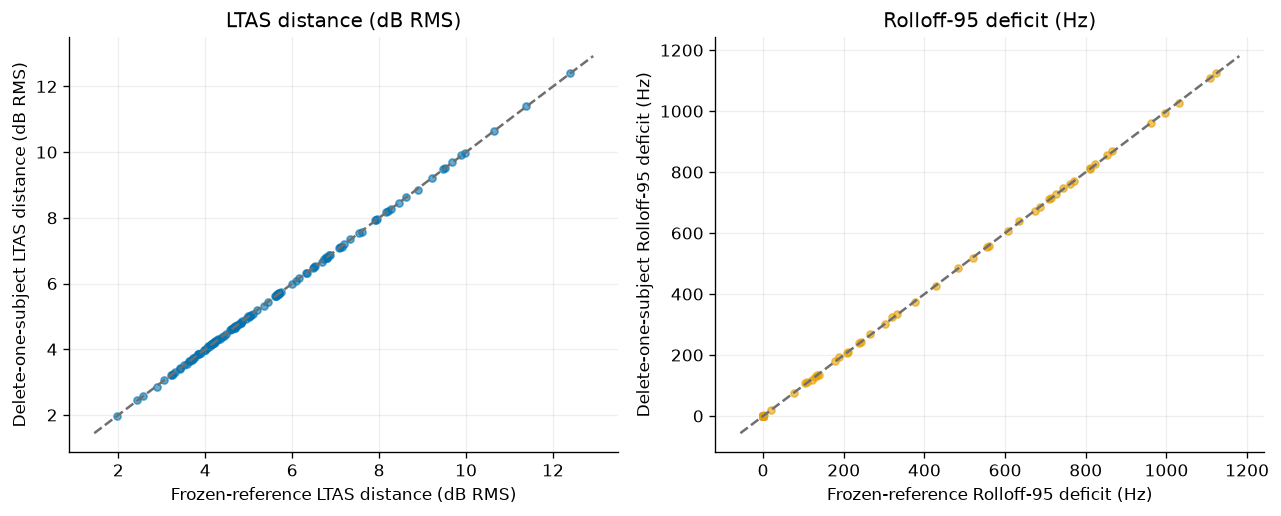

,condition,feature,paired_n,spearman_rho,median_absolute_delta
0,delete_one_reference_subject,qchan_ltas_distance_db,120,0.999861,0.009235
1,delete_one_reference_subject,qchan_rolloff95_deficit_hz,120,1.000000,0.000000
2,delete_one_reference_subject,qchan_highband_ratio_deficit,120,0.999871,0.000000
3,delete_one_reference_subject,qchan_tilt_steepening_db_per_oct,120,0.999950,0.000000
4,recording_weighted_reference,qchan_ltas_distance_db,120,0.993979,0.138336
5,recording_weighted_reference,qchan_rolloff95_deficit_hz,120,0.993423,0.000000
6,recording_weighted_reference,qchan_highband_ratio_deficit,120,0.987710,0.000000
7,recording_weighted_reference,qchan_tilt_steepening_db_per_oct,120,0.953980,0.000000


,feature,replicates,minimum_paired_n,spearman_rho_q05,spearman_rho_median,median_of_median_absolute_delta
0,qchan_ltas_distance_db,40,120,0.989153,0.992156,0.10369
1,qchan_rolloff95_deficit_hz,40,120,0.960585,0.979200,0.00000
2,qchan_highband_ratio_deficit,40,120,0.978047,0.987057,0.00000
3,qchan_tilt_steepening_db_per_oct,40,120,0.962100,0.978379,0.00000


,layer,check,passed,observed,required,action_if_failed,blocking
0,reference robustness,delete-one-subject paired support,True,"{'qchan_ltas_distance_db': 120, 'qchan_rolloff...",>=30 each,increase robustness sample or limit claim,True
1,reference robustness,delete-one-subject rank stability,True,"{'qchan_ltas_distance_db': 1.0, 'qchan_rolloff...",rho >=0.85 each,revise reference or qualify feature,True
2,reference robustness,recording-weighted alternative is audit-only,True,characterized,present but not used,restore subject-balancing comparison,True
3,reference robustness,subject-bootstrap paired support,True,"{'qchan_ltas_distance_db': 120, 'qchan_rolloff...",>=30 targets in all 40 replicates,increase robustness sample or limit claim,True
4,reference robustness,subject-bootstrap rank stability,True,"{'qchan_ltas_distance_db': 0.989, 'qchan_rollo...",5th-percentile rho >=0.80,revise reference or qualify feature,True


In [10]:
reference_robustness = pd.DataFrame()
reference_robustness_summary = pd.DataFrame()
reference_bootstrap_summary = pd.DataFrame()

def normalized_median_reference(psd_rows, frequencies):
    local = np.median(np.vstack(psd_rows), axis=0)
    mask = (
        (frequencies >= PARAMETERS.analysis_low_hz)
        & (frequencies <= PARAMETERS.analysis_high_hz)
    )
    total = np.trapezoid(local[mask], frequencies[mask])
    return local / total


def rebuild_reference(reference, *, delete_subject=None, recording_weighted=False):
    members = recording_spectrum_table.loc[
        recording_spectrum_table["logical_recording_id"].isin(
            reference.member_recording_ids
        ),
        ["logical_recording_id", "subject_id"],
    ].copy()
    if delete_subject is not None:
        members = members.loc[
            ~members["subject_id"].astype(str).eq(str(delete_subject))
        ]
    frequencies = reference.frequencies_hz
    if recording_weighted:
        rows = [
            spectra[str(recording_id)].normalized_psd_per_hz
            for recording_id in members["logical_recording_id"]
        ]
    else:
        rows = []
        for _, local in members.groupby("subject_id"):
            rows.append(normalized_median_reference(
                [
                    spectra[str(recording_id)].normalized_psd_per_hz
                    for recording_id in local["logical_recording_id"]
                ],
                frequencies,
            ))
    psd = normalized_median_reference(rows, frequencies)
    return ReferenceSpectrum(
        reference_key=reference.reference_key + "_sensitivity",
        task_stratum=reference.task_stratum,
        excluded_subject_id=reference.excluded_subject_id,
        frequencies_hz=frequencies,
        normalized_psd_per_hz=psd,
        status="measured",
        member_recording_ids=tuple(members["logical_recording_id"].astype(str)),
        member_subject_ids=tuple(sorted(members["subject_id"].astype(str).unique())),
        recording_count=len(members),
        subject_count=members["subject_id"].nunique(),
        reference_sha256="sensitivity",
        reference_vintage_sha256=reference.reference_vintage_sha256,
    )


def bootstrap_reference(reference, sampled_subjects):
    members = recording_spectrum_table.loc[
        recording_spectrum_table["logical_recording_id"].isin(
            reference.member_recording_ids
        ),
        ["logical_recording_id", "subject_id"],
    ].copy()
    frequencies = reference.frequencies_hz
    rows = []
    for subject_id in sampled_subjects:
        local = members.loc[
            members["subject_id"].astype(str).eq(str(subject_id))
        ]
        rows.append(normalized_median_reference(
            [
                spectra[str(recording_id)].normalized_psd_per_hz
                for recording_id in local["logical_recording_id"]
            ],
            frequencies,
        ))
    psd = normalized_median_reference(rows, frequencies)
    return ReferenceSpectrum(
        reference_key=reference.reference_key + "_bootstrap",
        task_stratum=reference.task_stratum,
        excluded_subject_id=reference.excluded_subject_id,
        frequencies_hz=frequencies,
        normalized_psd_per_hz=psd,
        status="measured",
        member_recording_ids=reference.member_recording_ids,
        member_subject_ids=tuple(str(value) for value in sampled_subjects),
        recording_count=reference.recording_count,
        subject_count=len(set(sampled_subjects)),
        reference_sha256="bootstrap_sensitivity",
        reference_vintage_sha256=reference.reference_vintage_sha256,
    )


if RUN_COHORT_EXTRACTION and len(analysis_feature_table):
    available = analysis_feature_table.loc[
        analysis_feature_table["qchan_family_status"].eq("measured")
    ].sample(
        n=min(REFERENCE_ROBUSTNESS_SAMPLE_N, int(analysis_feature_table["qchan_family_status"].eq("measured").sum())),
        random_state=PARAMETERS.random_seed,
    ).sort_values("logical_recording_id")
    rows = []
    for target in available.itertuples(index=False):
        recording_id = str(target.logical_recording_id)
        reference = references[recording_id]
        observation = spectra[recording_id]
        subjects = list(reference.member_subject_ids)
        delete_subject = subjects[
            int(hashlib.sha256(recording_id.encode()).hexdigest()[:8], 16)
            % len(subjects)
        ]
        alternatives = {
            "delete_one_reference_subject": rebuild_reference(
                reference, delete_subject=delete_subject
            ),
            "recording_weighted_reference": rebuild_reference(
                reference, recording_weighted=True
            ),
        }
        for condition, alternative in alternatives.items():
            changed = compute_reference_relative_features(
                observation, alternative
            )
            rows.append({
                "logical_recording_id": recording_id,
                "condition": condition,
                "replicate": -1,
                "deleted_subject": (
                    delete_subject
                    if condition == "delete_one_reference_subject" else pd.NA
                ),
                **{
                    f"{feature}_baseline": getattr(target, feature)
                    for feature in ANALYSIS_FEATURES
                },
                **{
                    f"{feature}_alternative": changed[feature]
                    for feature in ANALYSIS_FEATURES
                },
            })
        bootstrap_rng = np.random.default_rng(
            PARAMETERS.random_seed
            + int(hashlib.sha256(
                recording_id.encode()
            ).hexdigest()[:8], 16)
        )
        for replicate in range(REFERENCE_BOOTSTRAP_REPLICATES):
            sampled_subjects = bootstrap_rng.choice(
                subjects, size=len(subjects), replace=True
            ).tolist()
            alternative = bootstrap_reference(
                reference, sampled_subjects
            )
            changed = compute_reference_relative_features(
                observation, alternative
            )
            rows.append({
                "logical_recording_id": recording_id,
                "condition": "bootstrap_reference_subjects",
                "replicate": replicate,
                "deleted_subject": pd.NA,
                **{
                    f"{feature}_baseline": getattr(target, feature)
                    for feature in ANALYSIS_FEATURES
                },
                **{
                    f"{feature}_alternative": changed[feature]
                    for feature in ANALYSIS_FEATURES
                },
            })
    reference_robustness = pd.DataFrame(rows)
    summary_rows = []
    nonbootstrap = reference_robustness.loc[
        ~reference_robustness["condition"].eq(
            "bootstrap_reference_subjects"
        )
    ]
    for condition, local in nonbootstrap.groupby("condition"):
        for feature in ANALYSIS_FEATURES:
            paired = local[
                [f"{feature}_baseline", f"{feature}_alternative"]
            ].dropna()
            rho = (
                stats.spearmanr(
                    paired.iloc[:, 0], paired.iloc[:, 1]
                ).statistic
                if len(paired) >= 3 else np.nan
            )
            summary_rows.append({
                "condition": condition, "feature": feature,
                "paired_n": len(paired), "spearman_rho": rho,
                "median_absolute_delta": float(np.median(np.abs(
                    paired.iloc[:, 1] - paired.iloc[:, 0]
                ))) if len(paired) else np.nan,
            })
    reference_robustness_summary = pd.DataFrame(summary_rows)
    bootstrap_rows = []
    bootstrap = reference_robustness.loc[
        reference_robustness["condition"].eq(
            "bootstrap_reference_subjects"
        )
    ]
    for feature in ANALYSIS_FEATURES:
        replicate_rows = []
        for replicate, local in bootstrap.groupby("replicate"):
            paired = local[
                [f"{feature}_baseline", f"{feature}_alternative"]
            ].dropna()
            rho = (
                stats.spearmanr(
                    paired.iloc[:, 0], paired.iloc[:, 1]
                ).statistic
                if len(paired) >= 3 else np.nan
            )
            replicate_rows.append({
                "replicate": replicate,
                "paired_n": len(paired),
                "spearman_rho": rho,
                "median_absolute_delta": float(np.median(np.abs(
                    paired.iloc[:, 1] - paired.iloc[:, 0]
                ))) if len(paired) else np.nan,
            })
        replicate_frame = pd.DataFrame(replicate_rows)
        bootstrap_rows.append({
            "feature": feature,
            "replicates": len(replicate_frame),
            "minimum_paired_n": int(
                replicate_frame["paired_n"].min()
            ) if len(replicate_frame) else 0,
            "spearman_rho_q05": float(
                replicate_frame["spearman_rho"].quantile(0.05)
            ) if len(replicate_frame) else np.nan,
            "spearman_rho_median": float(
                replicate_frame["spearman_rho"].median()
            ) if len(replicate_frame) else np.nan,
            "median_of_median_absolute_delta": float(
                replicate_frame["median_absolute_delta"].median()
            ) if len(replicate_frame) else np.nan,
        })
    reference_bootstrap_summary = pd.DataFrame(bootstrap_rows)
    save_table_bundle(
        reference_robustness, TABLES, "qchan_v301_reference_robustness"
    )
    save_table_bundle(
        reference_robustness_summary, TABLES,
        "qchan_v301_reference_robustness_summary",
    )
    save_table_bundle(
        reference_bootstrap_summary, TABLES,
        "qchan_v301_reference_bootstrap_summary",
    )
    delete_rows = reference_robustness_summary.loc[
        reference_robustness_summary["condition"].eq(
            "delete_one_reference_subject"
        )
    ]
    reference_robustness_checks = validation_frame([
        ValidationCheck(
            "reference robustness", "delete-one-subject paired support",
            bool(delete_rows["paired_n"].ge(30).all()),
            str(delete_rows.set_index("feature")["paired_n"].to_dict()),
            ">=30 each", "increase robustness sample or limit claim",
        ),
        ValidationCheck(
            "reference robustness", "delete-one-subject rank stability",
            bool(delete_rows["spearman_rho"].ge(0.85).all()),
            str(delete_rows.set_index("feature")[
                "spearman_rho"
            ].round(3).to_dict()),
            "rho >=0.85 each", "revise reference or qualify feature",
        ),
        ValidationCheck(
            "reference robustness", "recording-weighted alternative is audit-only",
            bool((reference_robustness["condition"]
                  == "recording_weighted_reference").any()),
            "characterized", "present but not used",
            "restore subject-balancing comparison",
        ),
        ValidationCheck(
            "reference robustness", "subject-bootstrap paired support",
            bool(
                reference_bootstrap_summary[
                    "minimum_paired_n"
                ].ge(30).all()
                and reference_bootstrap_summary[
                    "replicates"
                ].eq(REFERENCE_BOOTSTRAP_REPLICATES).all()
            ),
            str(reference_bootstrap_summary.set_index("feature")[
                "minimum_paired_n"
            ].to_dict()),
            (
                f">=30 targets in all "
                f"{REFERENCE_BOOTSTRAP_REPLICATES} replicates"
            ),
            "increase robustness sample or limit claim",
        ),
        ValidationCheck(
            "reference robustness", "subject-bootstrap rank stability",
            bool(
                reference_bootstrap_summary[
                    "spearman_rho_q05"
                ].ge(0.80).all()
            ),
            str(reference_bootstrap_summary.set_index("feature")[
                "spearman_rho_q05"
            ].round(3).to_dict()),
            "5th-percentile rho >=0.80",
            "revise reference or qualify feature",
        ),
    ])

    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4))
    delete = reference_robustness.loc[
        reference_robustness["condition"].eq(
            "delete_one_reference_subject"
        )
    ]
    for ax, feature, color, label in [
        (
            axes[0], "qchan_ltas_distance_db",
            OKABE_ITO["blue"], "LTAS distance (dB RMS)",
        ),
        (
            axes[1], "qchan_rolloff95_deficit_hz",
            OKABE_ITO["orange"], "Rolloff-95 deficit (Hz)",
        ),
    ]:
        ax.scatter(
            delete[f"{feature}_baseline"],
            delete[f"{feature}_alternative"],
            s=18, alpha=0.6, color=color,
        )
        low = min(
            ax.get_xlim()[0], ax.get_ylim()[0]
        )
        high = max(
            ax.get_xlim()[1], ax.get_ylim()[1]
        )
        ax.plot(
            [low, high], [low, high], "--",
            color=OKABE_ITO["grey"],
        )
        ax.set(
            xlabel=f"Frozen-reference {label}",
            ylabel=f"Delete-one-subject {label}",
            title=label,
        )
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qchan_reference_robustness",
        caption=(
            "QCHAN primary-feature robustness after deleting one "
            "reference subject. Subject-bootstrap and rejected "
            "recording-weighted results are retained in companion tables."
        ),
        alt_text=(
            "Frozen-reference and delete-one-reference-subject values "
            "for LTAS distance and rolloff-95 deficit."
        ),
    )
    plt.show()
else:
    reference_robustness_checks = validation_frame([
        ValidationCheck(
            "reference robustness", "reference sensitivity completed",
            False, "NOT RUN", "completed", "enable cohort extraction",
        )
    ])
display(reference_robustness_summary)
display(reference_bootstrap_summary)
display(reference_robustness_checks)

## 9. Boundary, frame, support, and availability robustness

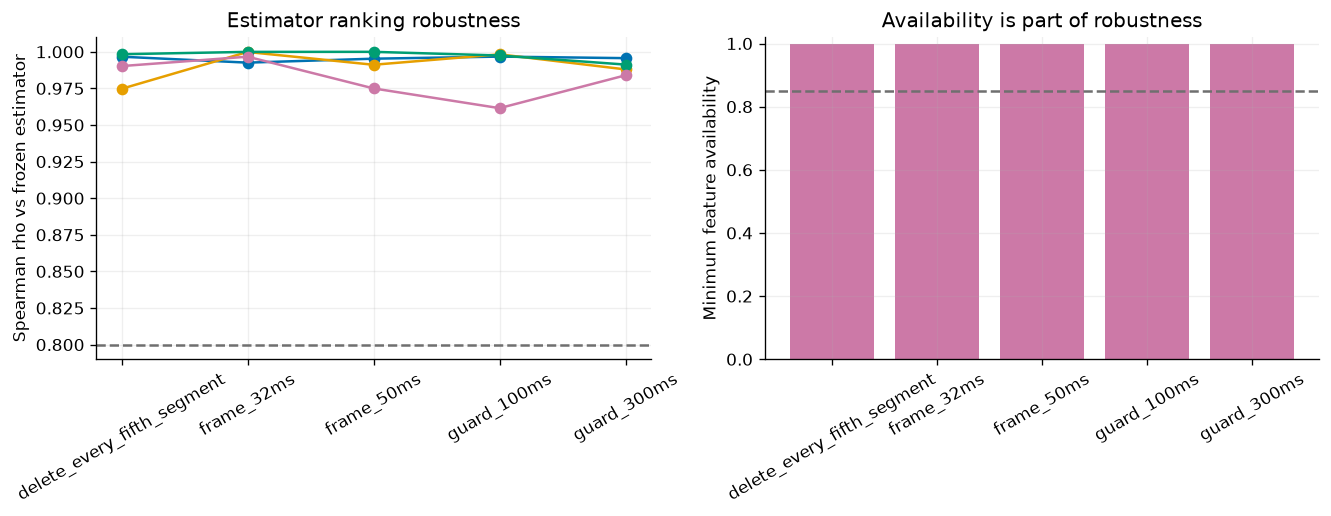

,condition,feature,paired_n,availability_fraction,spearman_rho,median_absolute_delta
0,delete_every_fifth_segment,qchan_ltas_distance_db,80,1.0,0.996648,0.065056
1,delete_every_fifth_segment,qchan_rolloff95_deficit_hz,80,1.0,0.974711,0.000000
2,delete_every_fifth_segment,qchan_highband_ratio_deficit,80,1.0,0.998348,0.000000
3,delete_every_fifth_segment,qchan_tilt_steepening_db_per_oct,80,1.0,0.990239,0.000000
4,frame_32ms,qchan_ltas_distance_db,80,1.0,0.992593,0.119979
5,frame_32ms,qchan_rolloff95_deficit_hz,80,1.0,0.999878,0.000000
6,frame_32ms,qchan_highband_ratio_deficit,80,1.0,0.999946,0.000000
7,frame_32ms,qchan_tilt_steepening_db_per_oct,80,1.0,0.996664,0.000000
8,frame_50ms,qchan_ltas_distance_db,80,1.0,0.995288,0.108256
9,frame_50ms,qchan_rolloff95_deficit_hz,80,1.0,0.991141,0.000000


,layer,check,passed,observed,required,action_if_failed,blocking
0,robustness,zero robustness execution errors,True,0,0,resolve robustness decode/estimator errors,True
1,robustness,minimum paired support,True,"{'qchan_highband_ratio_deficit': 80, 'qchan_lt...",>=30 per condition-feature,increase sample or limit claim,True
2,robustness,ranking stability,True,"{'qchan_highband_ratio_deficit': 0.991, 'qchan...",rho >=0.80,revise estimator/support,True
3,robustness,availability stability,True,"{'delete_every_fifth_segment': 1.0, 'frame_32m...",>=85%,revise support contract,True


In [11]:
robustness_table = pd.DataFrame()
robustness_summary = pd.DataFrame()

def delete_every_fifth(intervals):
    return [
        interval for index, interval in enumerate(intervals)
        if (index + 1) % 5 != 0
    ]


if RUN_COHORT_EXTRACTION and len(analysis_feature_table):
    robustness_candidates = analysis_feature_table.loc[
        analysis_feature_table["qchan_family_status"].eq("measured")
    ].sample(
        n=min(ROBUSTNESS_SAMPLE_N, int(analysis_feature_table["qchan_family_status"].eq("measured").sum())),
        random_state=PARAMETERS.random_seed + 1,
    ).sort_values("logical_recording_id")
    row_lookup = frozen["recordings"].set_index("logical_recording_id")
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    variants = {
        "guard_100ms": replace(PARAMETERS, speech_boundary_guard_ms=100.0),
        "guard_300ms": replace(PARAMETERS, speech_boundary_guard_ms=300.0),
        "frame_32ms": replace(PARAMETERS, frame_ms=32.0),
        "frame_50ms": replace(PARAMETERS, frame_ms=50.0),
        "delete_every_fifth_segment": PARAMETERS,
    }
    rows, errors = [], []
    for target in robustness_candidates.itertuples(index=False):
        recording_id = str(target.logical_recording_id)
        views = None
        try:
            source_row = row_lookup.loc[recording_id]
            views = decode_audio_views(
                media_path_for(source_row), ffmpeg=ffmpeg, ffprobe=ffprobe,
                analysis_rate=FS,
            )
            original_intervals = intervals_for(recording_id)
            for condition, local_parameters in variants.items():
                local_intervals = (
                    delete_every_fifth(original_intervals)
                    if condition == "delete_every_fifth_segment"
                    else original_intervals
                )
                observed = extract_recording_spectrum(
                    views.analysis_16k, FS,
                    strict_speech=local_intervals,
                    logical_recording_id=recording_id,
                    source_sample_rate_hz=views.sample_rate_native,
                    parameters=local_parameters,
                )
                changed = compute_reference_relative_features(
                    observed, references[recording_id],
                    parameters=local_parameters,
                )
                rows.append({
                    "logical_recording_id": recording_id,
                    "condition": condition,
                    "available": changed["qchan_family_status"] == "measured",
                    **{
                        f"{feature}_baseline": getattr(target, feature)
                        for feature in ANALYSIS_FEATURES
                    },
                    **{
                        f"{feature}_alternative": changed[feature]
                        for feature in ANALYSIS_FEATURES
                    },
                })
        except Exception as exc:
            errors.append({
                "logical_recording_id": recording_id,
                "error_type": type(exc).__name__, "message": str(exc),
            })
        finally:
            views = None
            gc.collect()
    robustness_table = pd.DataFrame(rows)
    robustness_errors = pd.DataFrame(
        errors,
        columns=["logical_recording_id", "condition", "error_type", "message"],
    )
    summary_rows = []
    for condition, local in robustness_table.groupby("condition"):
        for feature in ANALYSIS_FEATURES:
            paired = local[
                [f"{feature}_baseline", f"{feature}_alternative"]
            ].dropna()
            rho = (
                stats.spearmanr(
                    paired.iloc[:, 0], paired.iloc[:, 1]
                ).statistic
                if len(paired) >= 3 else np.nan
            )
            summary_rows.append({
                "condition": condition, "feature": feature,
                "paired_n": len(paired),
                "availability_fraction": float(local["available"].mean()),
                "spearman_rho": rho,
                "median_absolute_delta": float(np.median(np.abs(
                    paired.iloc[:, 1] - paired.iloc[:, 0]
                ))) if len(paired) else np.nan,
            })
    robustness_summary = pd.DataFrame(summary_rows)
    save_table_bundle(
        robustness_table, TABLES, "qchan_v301_support_boundary_robustness"
    )
    save_table_bundle(
        robustness_summary, TABLES,
        "qchan_v301_support_boundary_robustness_summary",
    )
    save_table_bundle(
        robustness_errors, AUDIT, "qchan_v301_robustness_errors"
    )
    robustness_checks = validation_frame([
        ValidationCheck(
            "robustness", "zero robustness execution errors",
            robustness_errors.empty, str(len(robustness_errors)), "0",
            "resolve robustness decode/estimator errors",
        ),
        ValidationCheck(
            "robustness", "minimum paired support",
            bool(robustness_summary["paired_n"].ge(30).all()),
            str(robustness_summary.groupby("feature")[
                "paired_n"
            ].min().to_dict()),
            ">=30 per condition-feature", "increase sample or limit claim",
        ),
        ValidationCheck(
            "robustness", "ranking stability",
            bool(robustness_summary["spearman_rho"].ge(0.80).all()),
            str(robustness_summary.groupby("feature")[
                "spearman_rho"
            ].min().round(3).to_dict()),
            "rho >=0.80", "revise estimator/support",
        ),
        ValidationCheck(
            "robustness", "availability stability",
            bool(robustness_summary["availability_fraction"].ge(0.85).all()),
            str(robustness_summary.groupby("condition")[
                "availability_fraction"
            ].min().round(3).to_dict()),
            ">=85%", "revise support contract",
        ),
    ])
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
    for feature, color in zip(
        ANALYSIS_FEATURES,
        [OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["green"], OKABE_ITO["purple"]],
    ):
        local = robustness_summary.loc[
            robustness_summary["feature"].eq(feature)
        ]
        axes[0].plot(
            local["condition"], local["spearman_rho"],
            "o-", label=feature, color=color,
        )
    axes[0].axhline(0.80, color=OKABE_ITO["grey"], linestyle="--")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set(
        ylabel="Spearman rho vs frozen estimator",
        title="Estimator ranking robustness",
    )
    availability = robustness_summary.groupby(
        "condition"
    )["availability_fraction"].min()
    axes[1].bar(
        availability.index, availability.values,
        color=OKABE_ITO["purple"],
    )
    axes[1].axhline(0.85, color=OKABE_ITO["grey"], linestyle="--")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].set(
        ylabel="Minimum feature availability",
        ylim=(0, 1.02), title="Availability is part of robustness",
    )
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qchan_support_boundary_robustness",
        caption="QCHAN boundary, frame, whole-segment deletion, and availability robustness.",
        alt_text="Feature rank correlations and availability under prespecified estimator perturbations.",
    )
    plt.show()
else:
    robustness_checks = validation_frame([
        ValidationCheck(
            "robustness", "zero robustness execution errors",
            robustness_errors.empty, str(len(robustness_errors)), "0",
            "resolve robustness decode/estimator errors",
        ),
        ValidationCheck(
            "robustness", "cohort robustness completed",
            False, "NOT RUN", "completed", "enable cohort extraction",
        )
    ])
display(robustness_summary)
display(robustness_checks)

## 10. Empirical distributions, availability, and redundancy

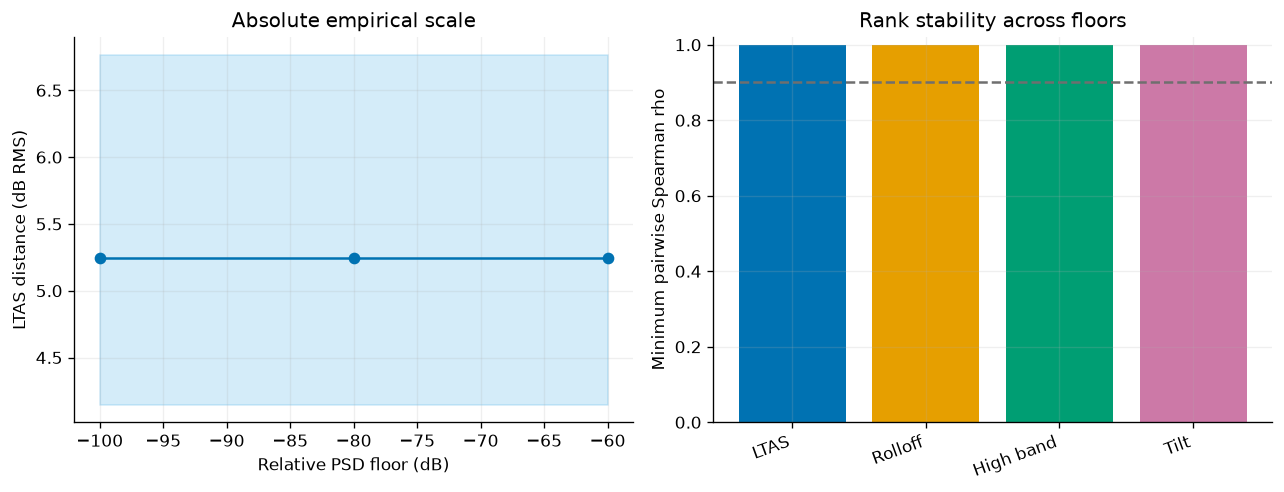

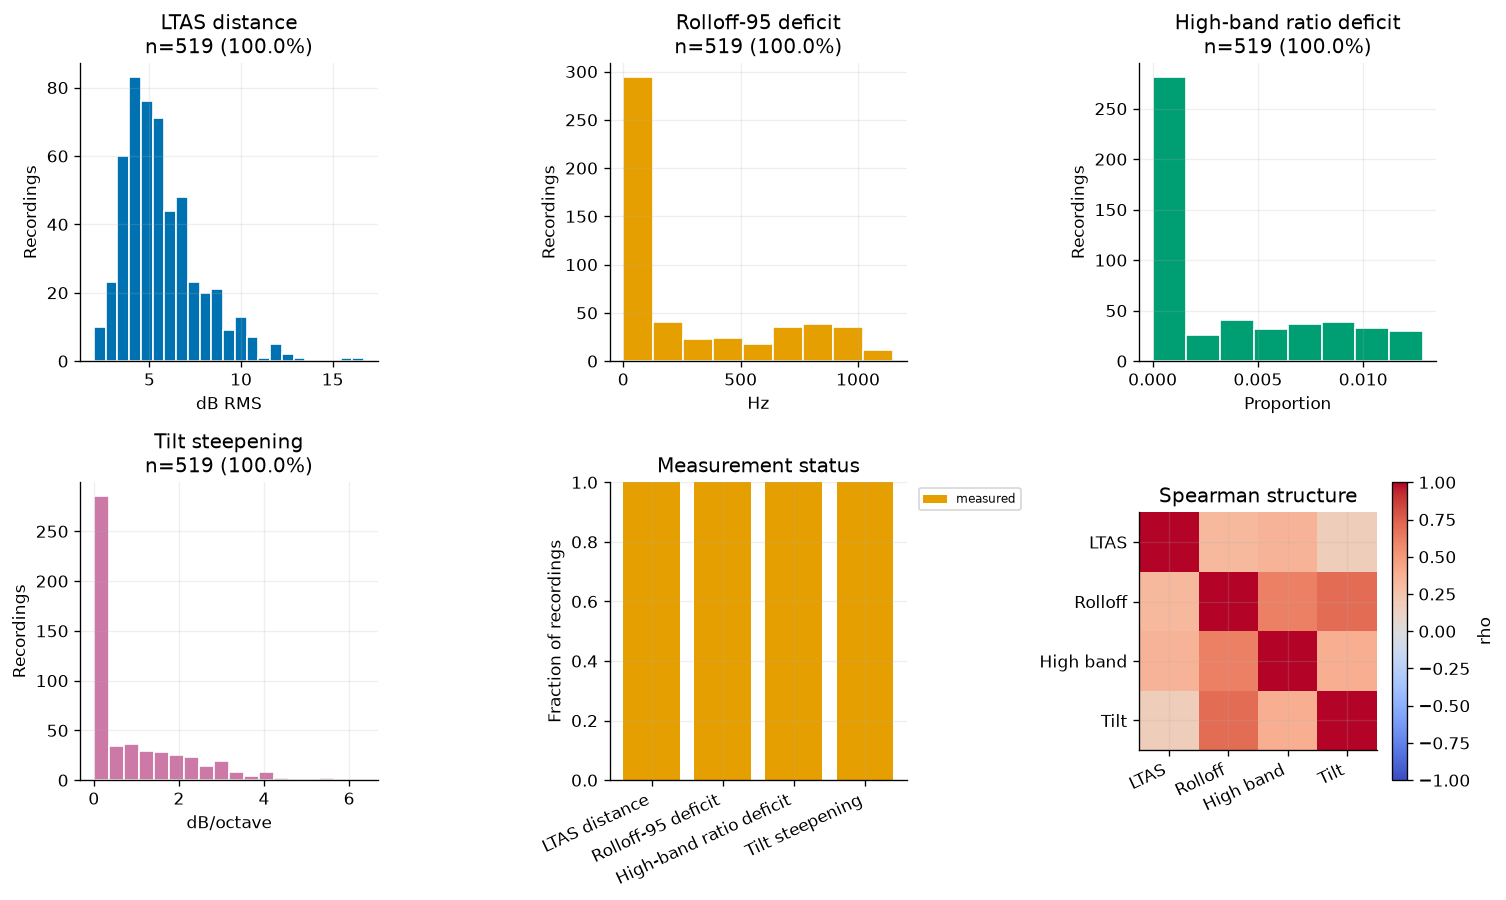

,feature,available_n,availability_fraction,minimum,q01,q25,median,q75,q99,maximum
0,qchan_ltas_distance_db,519,1.0,1.967705,2.377924,4.146645,5.241467,6.766327,12.101269,16.713480
1,qchan_rolloff95_deficit_hz,519,1.0,0.000000,0.000000,0.000000,0.000000,560.348101,1080.457004,1150.911767
2,qchan_highband_ratio_deficit,519,1.0,0.000000,0.000000,0.000000,0.000560,0.006878,0.012328,0.012833
3,qchan_tilt_steepening_db_per_oct,519,1.0,0.000000,0.000000,0.000000,0.074576,1.483114,4.306222,6.351059


,feature_a,feature_b,paired_n,spearman_rho,absolute_rho,interpretation
0,qchan_ltas_distance_db,qchan_rolloff95_deficit_hz,519,0.320354,0.320354,not near-duplicate by prespecified threshold
1,qchan_ltas_distance_db,qchan_highband_ratio_deficit,519,0.354284,0.354284,not near-duplicate by prespecified threshold
2,qchan_ltas_distance_db,qchan_tilt_steepening_db_per_oct,519,0.178679,0.178679,not near-duplicate by prespecified threshold
3,qchan_rolloff95_deficit_hz,qchan_highband_ratio_deficit,519,0.616460,0.616460,not near-duplicate by prespecified threshold
4,qchan_rolloff95_deficit_hz,qchan_tilt_steepening_db_per_oct,519,0.702944,0.702944,not near-duplicate by prespecified threshold
5,qchan_highband_ratio_deficit,qchan_tilt_steepening_db_per_oct,519,0.389672,0.389672,not near-duplicate by prespecified threshold


,layer,check,passed,observed,required,action_if_failed,blocking
0,empirical,all four features are characterizable,True,"{'qchan_ltas_distance_db': 519, 'qchan_rolloff...",>=26 each,limit claims or revise reference/support,True
1,empirical,availability/status summary is complete,True,checked,all four,repair status export,True
2,empirical,redundancy is explicitly audited,True,6,six feature pairs,restore G8 redundancy audit,True
3,empirical,real-cohort floor ranking is stable from cache...,True,"{'qchan_ltas_distance_db': 1.0, 'qchan_rolloff...",minimum pairwise Spearman rho >=0.90; absolute...,reconsider floor or qualify estimator scale,True
4,empirical,phenotype-confounding analysis is prespecified...,True,specified,label-blind phenotype audit plus single-task s...,restore scientific firewall,True


In [12]:
empirical_summary = pd.DataFrame()
availability_summary = pd.DataFrame()
correlation_table = pd.DataFrame()
redundancy_table = pd.DataFrame()
empirical_floor_sensitivity = pd.DataFrame()
empirical_floor_sensitivity_summary = pd.DataFrame()
downstream_phenotype_specification = pd.DataFrame([
    {
        "analysis_stage": "downstream scientific analysis only",
        "question": (
            "Are QCHAN estimates or availability associated with diagnosis, "
            "bulbar severity, sex, age, or other phenotype variables?"
        ),
        "current_notebook_scope": (
            "no clinical or human-QC labels used; extraction remains label-blind"
        ),
        "required_interpretation": (
            "QCHAN is not assumed phenotype-independent; associations bound "
            "construct purity and cannot be used to retune extraction."
        ),
    },
    {
        "analysis_stage": "scope limitation / future validation",
        "question": (
            "Are QCHAN values stable across different speech tasks within subject?"
        ),
        "current_notebook_scope": (
            "not estimable: the frozen manuscript cohort contains one fixed "
            "Bamboo connected-speech task"
        ),
        "required_interpretation": (
            "No cross-task generalization claim; a new task requires a separate "
            "task-matched frozen reference and validation vintage."
        ),
    },
])
if RUN_COHORT_EXTRACTION and len(analysis_feature_table):
    rows, status_rows = [], []
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(
            analysis_feature_table[feature], errors="coerce"
        )
        finite = values.dropna()
        rows.append({
            "feature": feature,
            "available_n": len(finite),
            "availability_fraction": len(finite) / len(analysis_feature_table),
            "minimum": finite.min() if len(finite) else np.nan,
            "q01": finite.quantile(0.01) if len(finite) else np.nan,
            "q25": finite.quantile(0.25) if len(finite) else np.nan,
            "median": finite.median() if len(finite) else np.nan,
            "q75": finite.quantile(0.75) if len(finite) else np.nan,
            "q99": finite.quantile(0.99) if len(finite) else np.nan,
            "maximum": finite.max() if len(finite) else np.nan,
        })
        counts = analysis_feature_table[
            f"{feature}_status"
        ].astype(str).value_counts(dropna=False)
        for status, count in counts.items():
            status_rows.append({
                "feature": feature, "status": status,
                "count": int(count),
                "fraction": count / len(analysis_feature_table),
            })
    empirical_summary = pd.DataFrame(rows)
    availability_summary = pd.DataFrame(status_rows)
    correlation_table = analysis_feature_table[
        list(ANALYSIS_FEATURES)
    ].corr(method="spearman", min_periods=20)
    redundancy_rows = []
    for index, feature_a in enumerate(ANALYSIS_FEATURES):
        for feature_b in ANALYSIS_FEATURES[index + 1:]:
            paired = analysis_feature_table[
                [feature_a, feature_b]
            ].apply(pd.to_numeric, errors="coerce").dropna()
            rho = (
                stats.spearmanr(
                    paired[feature_a], paired[feature_b]
                ).statistic
                if len(paired) >= 3 else np.nan
            )
            redundancy_rows.append({
                "feature_a": feature_a, "feature_b": feature_b,
                "paired_n": len(paired), "spearman_rho": rho,
                "absolute_rho": abs(rho) if np.isfinite(rho) else np.nan,
                "interpretation": (
                    "high redundancy; retain distinct estimand roles"
                    if np.isfinite(rho) and abs(rho) >= 0.90
                    else "not near-duplicate by prespecified threshold"
                ),
            })
    redundancy_table = pd.DataFrame(redundancy_rows)

    floor_rows = []
    for recording_id in analysis_feature_table["logical_recording_id"].astype(str):
        observation = spectra.get(recording_id)
        reference = references.get(recording_id)
        if (
            observation is None
            or reference is None
            or observation.status != "measured"
            or reference.status != "measured"
        ):
            continue
        for floor_db in [-60.0, -80.0, -100.0]:
            local_parameters = replace(
                PARAMETERS, relative_psd_floor_db=floor_db
            )
            result = compute_reference_relative_features(
                observation,
                reference,
                parameters=local_parameters,
            )
            floor_rows.append({
                "logical_recording_id": recording_id,
                "relative_psd_floor_db": floor_db,
                **{
                    feature: result[feature]
                    for feature in ANALYSIS_FEATURES
                },
            })
    empirical_floor_sensitivity = pd.DataFrame(floor_rows)
    floor_summary_rows = []
    for feature in ANALYSIS_FEATURES:
        pivot = empirical_floor_sensitivity.pivot(
            index="logical_recording_id",
            columns="relative_psd_floor_db",
            values=feature,
        )
        pairwise = pivot.corr(method="spearman").to_numpy()
        finite_pairwise = pairwise[np.isfinite(pairwise)]
        minimum_rho = (
            float(np.min(finite_pairwise))
            if finite_pairwise.size else np.nan
        )
        within_recording_range = pivot.max(axis=1) - pivot.min(axis=1)
        floor_summary_rows.append({
            "feature": feature,
            "recordings_n": int(pivot.notna().all(axis=1).sum()),
            "minimum_pairwise_spearman": minimum_rho,
            "median_within_recording_range": float(
                within_recording_range.median()
            ),
            "q95_within_recording_range": float(
                within_recording_range.quantile(0.95)
            ),
            "maximum_within_recording_range": float(
                within_recording_range.max()
            ),
            "interpretation": (
                "Rank stability is the gate. Absolute LTAS-distance and "
                "tilt scale may depend on the frozen floor when bands "
                "approach zero power."
            ),
        })
    empirical_floor_sensitivity_summary = pd.DataFrame(
        floor_summary_rows
    )

    for frame, stem in [
        (empirical_summary, "qchan_v301_empirical_summary"),
        (availability_summary, "qchan_v301_availability_summary"),
        (correlation_table.reset_index().rename(
            columns={"index": "feature"}
        ), "qchan_v301_spearman_correlations"),
        (redundancy_table, "qchan_v301_redundancy_audit"),
        (empirical_floor_sensitivity,
         "qchan_v301_empirical_floor_sensitivity"),
        (empirical_floor_sensitivity_summary,
         "qchan_v301_empirical_floor_sensitivity_summary"),
        (downstream_phenotype_specification,
         "qchan_v301_downstream_phenotype_specification"),
    ]:
        save_table_bundle(frame, TABLES, stem)
    minimum_empirical_n = max(
        20, math.ceil(0.05 * len(analysis_feature_table))
    )
    empirical_checks = validation_frame([
        ValidationCheck(
            "empirical", "all four features are characterizable",
            bool(empirical_summary["available_n"].ge(
                minimum_empirical_n
            ).all()),
            str(empirical_summary.set_index("feature")[
                "available_n"
            ].to_dict()),
            f">={minimum_empirical_n} each",
            "limit claims or revise reference/support",
        ),
        ValidationCheck(
            "empirical", "availability/status summary is complete",
            set(availability_summary["feature"]) == set(ANALYSIS_FEATURES),
            "checked", "all four", "repair status export",
        ),
        ValidationCheck(
            "empirical", "redundancy is explicitly audited",
            len(redundancy_table) == 6,
            str(len(redundancy_table)), "six feature pairs",
            "restore G8 redundancy audit",
        ),
        ValidationCheck(
            "empirical", "real-cohort floor ranking is stable from cached spectra",
            bool(
                len(empirical_floor_sensitivity_summary)
                and empirical_floor_sensitivity_summary[
                    "minimum_pairwise_spearman"
                ].ge(0.90).all()
            ),
            str(
                empirical_floor_sensitivity_summary.set_index("feature")[
                    "minimum_pairwise_spearman"
                ].round(3).to_dict()
            ),
            "minimum pairwise Spearman rho >=0.90; absolute scale dependence reported",
            "reconsider floor or qualify estimator scale",
        ),
        ValidationCheck(
            "empirical", "phenotype-confounding analysis is prespecified downstream",
            set(downstream_phenotype_specification["analysis_stage"]) == {
                "downstream scientific analysis only",
                "scope limitation / future validation",
            }
            and downstream_phenotype_specification.loc[
                downstream_phenotype_specification["analysis_stage"].eq(
                    "downstream scientific analysis only"
                ),
                "current_notebook_scope",
            ].str.contains("no clinical").all()
            and downstream_phenotype_specification.loc[
                downstream_phenotype_specification["analysis_stage"].eq(
                    "scope limitation / future validation"
                ),
                "required_interpretation",
            ].str.contains("No cross-task generalization").all(),
            "specified", "label-blind phenotype audit plus single-task scope",
            "restore scientific firewall",
        ),
    ])

    fig_floor, floor_axes = plt.subplots(1, 2, figsize=(10.8, 4.2))
    ltas_floor = empirical_floor_sensitivity.groupby(
        "relative_psd_floor_db"
    )["qchan_ltas_distance_db"]
    floor_median = ltas_floor.median().sort_index()
    floor_q25 = ltas_floor.quantile(0.25).reindex(floor_median.index)
    floor_q75 = ltas_floor.quantile(0.75).reindex(floor_median.index)
    floor_axes[0].plot(
        floor_median.index,
        floor_median.values,
        "o-",
        color=OKABE_ITO["blue"],
    )
    floor_axes[0].fill_between(
        floor_median.index,
        floor_q25.values,
        floor_q75.values,
        color=OKABE_ITO["sky"],
        alpha=0.25,
    )
    floor_axes[0].set(
        xlabel="Relative PSD floor (dB)",
        ylabel="LTAS distance (dB RMS)",
        title="Absolute empirical scale",
    )
    floor_axes[1].bar(
        np.arange(len(empirical_floor_sensitivity_summary)),
        empirical_floor_sensitivity_summary[
            "minimum_pairwise_spearman"
        ],
        color=[
            OKABE_ITO["blue"], OKABE_ITO["orange"],
            OKABE_ITO["green"], OKABE_ITO["purple"],
        ],
    )
    floor_axes[1].axhline(
        0.90, color=OKABE_ITO["grey"], linestyle="--"
    )
    floor_axes[1].set_xticks(
        np.arange(len(empirical_floor_sensitivity_summary)),
        ["LTAS", "Rolloff", "High band", "Tilt"],
        rotation=20,
        ha="right",
    )
    floor_axes[1].set(
        ylabel="Minimum pairwise Spearman rho",
        ylim=(0, 1.02),
        title="Rank stability across floors",
    )
    fig_floor.tight_layout()
    save_publication_figure(
        fig_floor,
        FIGURES,
        "figure_qchan_empirical_floor_sensitivity",
        caption=(
            "Real-cohort QCHAN logarithmic-floor sensitivity computed from "
            "cached spectra. Ranking is the validation target; absolute "
            "LTAS-distance scale is explicitly floor-dependent."
        ),
        alt_text=(
            "Median and interquartile LTAS distance across three logarithmic "
            "floors, plus minimum pairwise rank correlation for each feature."
        ),
    )
    plt.show()

    fig, axes = plt.subplots(2, 3, figsize=(12.6, 7.6))
    labels = {
        "qchan_ltas_distance_db": ("LTAS distance", "dB RMS"),
        "qchan_rolloff95_deficit_hz": ("Rolloff-95 deficit", "Hz"),
        "qchan_highband_ratio_deficit": ("High-band ratio deficit", "Proportion"),
        "qchan_tilt_steepening_db_per_oct": ("Tilt steepening", "dB/octave"),
    }
    for ax, feature, color in zip(
        axes.flat[:4], ANALYSIS_FEATURES,
        [OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["green"], OKABE_ITO["purple"]],
    ):
        values = pd.to_numeric(
            analysis_feature_table[feature], errors="coerce"
        ).dropna()
        ax.hist(
            values, bins="fd" if len(values) > 1 else 1,
            color=color, edgecolor="white",
        )
        ax.set(
            xlabel=labels[feature][1], ylabel="Recordings",
            title=f"{labels[feature][0]}\nn={len(values)} ({100*len(values)/len(analysis_feature_table):.1f}%)",
        )
    status_pivot = availability_summary.pivot(
        index="feature", columns="status", values="fraction"
    ).fillna(0).reindex(ANALYSIS_FEATURES)
    bottom = np.zeros(len(status_pivot))
    for index, status in enumerate(status_pivot.columns):
        axes[1, 1].bar(
            np.arange(len(status_pivot)), status_pivot[status],
            bottom=bottom, label=status,
            color=list(OKABE_ITO.values())[index % 8],
        )
        bottom += status_pivot[status].to_numpy()
    axes[1, 1].set_xticks(
        np.arange(len(status_pivot)),
        [labels[name][0] for name in status_pivot.index],
        rotation=25, ha="right",
    )
    axes[1, 1].set(
        ylabel="Fraction of recordings", ylim=(0, 1),
        title="Measurement status",
    )
    axes[1, 1].legend(
        fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left"
    )
    image = axes[1, 2].imshow(
        correlation_table.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm"
    )
    axes[1, 2].set_xticks(
        np.arange(4), ["LTAS", "Rolloff", "High band", "Tilt"],
        rotation=25, ha="right",
    )
    axes[1, 2].set_yticks(
        np.arange(4), ["LTAS", "Rolloff", "High band", "Tilt"]
    )
    axes[1, 2].set_title("Spearman structure")
    fig.colorbar(image, ax=axes[1, 2], label="rho")
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qchan_empirical_distributions",
        caption="QCHAN empirical distributions, measurement availability, and within-family rank-correlation structure.",
        alt_text="Four feature histograms, a stacked status chart, and a four-by-four Spearman correlation heatmap.",
    )
    plt.show()
else:
    empirical_checks = validation_frame([
        ValidationCheck(
            "empirical", "cohort characterization completed",
            False, "NOT RUN", "completed", "enable cohort extraction",
        )
    ])
display(empirical_summary)
display(redundancy_table)
display(empirical_checks)

## 11. Legacy disposition and analysis boundary

In [13]:
legacy_disposition = pd.DataFrame([
    {
        "legacy_item": "raw spectral centroid",
        "decision": "audit-only / not an analysis feature",
        "reason": "strongly phenotype- and phonetic-content-dependent; not channel-specific",
    },
    {
        "legacy_item": "raw spectral flatness",
        "decision": "audit-only / not an analysis feature",
        "reason": "responds strongly to additive noise and speech content",
    },
    {
        "legacy_item": "raw low- and mid-band ratios",
        "decision": "audit-only / not analysis features",
        "reason": "descriptive speech-spectrum measures without a defensible channel direction",
    },
    {
        "legacy_item": "absolute tilt deviation",
        "decision": "removed",
        "reason": "overlaps LTAS distance and adds phenotype-sensitive redundancy",
    },
    {
        "legacy_item": "recording-weighted LOSO reference",
        "decision": "rejected",
        "reason": "overweights subjects with repeated recordings",
    },
    {
        "legacy_item": "global cross-task fallback",
        "decision": "prohibited",
        "reason": "changes the estimand and weakens reference identity",
    },
    {
        "legacy_item": "family scalar",
        "decision": "prohibited",
        "reason": "no validated common direction or weighting",
    },
])
negative_checks = validation_frame([
    ValidationCheck(
        "analysis boundary", "legacy items are outside analysis profile",
        not set(legacy_disposition["legacy_item"]).intersection(
            set(ANALYSIS_FEATURES)
        ),
        "separated", "separated", "repair registry",
    ),
    ValidationCheck(
        "analysis boundary", "reference vintage limitation is explicit",
        "reference_limitation" in claim_contract,
        claim_contract["reference_limitation"],
        "explicit", "restore reviewer-requested limitation",
    ),
    ValidationCheck(
        "analysis boundary", "single-task generalization boundary is explicit",
        "task_scope" in claim_contract
        and "no cross-task generalization" in claim_contract["task_scope"].lower(),
        claim_contract.get("task_scope"),
        "explicit single-task limitation",
        "restore task-sensitivity boundary",
    ),
    ValidationCheck(
        "analysis boundary", "phenotype confounding is explicit",
        "ALS speech phenotype" in claim_contract["residual_confounding"],
        str(claim_contract["residual_confounding"]),
        "explicit", "restore claim boundary",
    ),
])
save_table_bundle(
    legacy_disposition, TABLES, "qchan_v301_legacy_disposition"
)
display(legacy_disposition)
display(negative_checks)

,legacy_item,decision,reason
0,raw spectral centroid,audit-only / not an analysis feature,strongly phenotype- and phonetic-content-depen...
1,raw spectral flatness,audit-only / not an analysis feature,responds strongly to additive noise and speech...
2,raw low- and mid-band ratios,audit-only / not analysis features,descriptive speech-spectrum measures without a...
3,absolute tilt deviation,removed,overlaps LTAS distance and adds phenotype-sens...
4,recording-weighted LOSO reference,rejected,overweights subjects with repeated recordings
5,global cross-task fallback,prohibited,changes the estimand and weakens reference ide...
6,family scalar,prohibited,no validated common direction or weighting


,layer,check,passed,observed,required,action_if_failed,blocking
0,analysis boundary,legacy items are outside analysis profile,True,separated,separated,repair registry,True
1,analysis boundary,reference vintage limitation is explicit,True,Comparable only within a frozen reference vint...,explicit,restore reviewer-requested limitation,True
2,analysis boundary,single-task generalization boundary is explicit,True,This study contains one fixed connected-speech...,explicit single-task limitation,restore task-sensitivity boundary,True
3,analysis boundary,phenotype confounding is explicit,True,"['ALS speech phenotype', 'phonetic composition...",explicit,restore claim boundary,True


## 12. Label-blind scientific gallery

In [14]:
gallery_index = pd.DataFrame()

def choose_gallery(table):
    candidates = []

    def add_nearest(local, feature, target, reason):
        if not len(local) or not np.isfinite(target):
            return
        values = pd.to_numeric(local[feature], errors="coerce")
        index = (values - target).abs().idxmin()
        candidates.append((
            str(local.loc[index, "logical_recording_id"]),
            reason,
        ))

    ltas_feature = "qchan_ltas_distance_db"
    ltas = table.loc[
        pd.to_numeric(table[ltas_feature], errors="coerce").notna()
    ]
    for quantile in [0.05, 0.50, 0.95]:
        if len(ltas):
            add_nearest(
                ltas,
                ltas_feature,
                float(ltas[ltas_feature].quantile(quantile)),
                f"{ltas_feature}_q{int(100 * quantile):02d}",
            )

    directional_features = [
        "qchan_rolloff95_deficit_hz",
        "qchan_highband_ratio_deficit",
        "qchan_tilt_steepening_db_per_oct",
    ]
    for feature in directional_features:
        values = pd.to_numeric(table[feature], errors="coerce")
        finite = table.loc[values.notna()].copy()
        finite_values = pd.to_numeric(finite[feature], errors="coerce")
        zero = finite.loc[np.isclose(finite_values, 0.0, atol=1e-12)]
        positive = finite.loc[finite_values.gt(0.0)]
        if len(zero):
            candidates.append((
                str(zero.iloc[0]["logical_recording_id"]),
                f"{feature}_zero",
            ))
        for quantile in [0.10, 0.50, 0.90]:
            if len(positive):
                add_nearest(
                    positive,
                    feature,
                    float(positive[feature].quantile(quantile)),
                    f"{feature}_positive_q{int(100 * quantile):02d}",
                )

    for reason, mask, sort_column, ascending in [
        (
            "minimum_support_audit",
            table["qchan_support_tier"].eq("minimum"),
            "qchan_guarded_speech_support_sec", True,
        ),
        (
            "source_bandwidth_audit",
            table["qchan_source_bandwidth_limited"].astype(bool),
            "qchan_source_nyquist_hz", True,
        ),
        (
            "reference_unavailable_audit",
            table["qchan_family_status"].eq("reference_unavailable"),
            "qchan_reference_subject_count", False,
        ),
    ]:
        for recording_id in table.loc[mask].sort_values(
            sort_column, ascending=ascending
        ).head(2)["logical_recording_id"]:
            candidates.append((str(recording_id), reason))
    frame = pd.DataFrame(
        candidates,
        columns=["logical_recording_id", "selection_reason"],
    )
    if not len(frame):
        return frame
    return (
        frame.groupby("logical_recording_id", as_index=False, sort=False)[
            "selection_reason"
        ].agg(";".join).head(24)
    )


def plot_gallery_recording(recording_id, reason):
    row = recording_feature_table.set_index(
        "logical_recording_id"
    ).loc[str(recording_id)]
    observation = spectra[str(recording_id)]
    reference = references[str(recording_id)]
    _, spectrum_path = checkpoint_paths(recording_id)
    archive = np.load(spectrum_path, allow_pickle=False)
    preview_time = archive["waveform_preview_time_sec"]
    preview_amplitude = archive["waveform_preview_amplitude"]
    fig, axes = plt.subplots(3, 1, figsize=(10.4, 7.6))
    axes[0].plot(
        preview_time, preview_amplitude,
        color=OKABE_ITO["grey"], linewidth=0.5,
    )
    for interval in intervals_for(recording_id):
        axes[0].axvspan(
            interval.start_sec, interval.end_sec,
            color=OKABE_ITO["sky"], alpha=0.13,
        )
    axes[0].set(
        xlabel="Original recording time (s)", ylabel="Amplitude",
        title=f"{recording_id} — {reason.replace('_', ' ')}",
    )
    if reference.status == "measured" and observation.status == "measured":
        centers, observed_ltas = smoothed_log_ltas_db(
            observation.frequencies_hz,
            observation.normalized_psd_per_hz,
        )
        _, reference_ltas = smoothed_log_ltas_db(
            reference.frequencies_hz,
            reference.normalized_psd_per_hz,
        )
        axes[1].semilogx(
            centers, observed_ltas, "o-",
            color=OKABE_ITO["blue"], label="target",
        )
        axes[1].semilogx(
            centers, reference_ltas, "o-",
            color=OKABE_ITO["orange"], label="frozen LOSO reference",
        )
        axes[1].axvspan(
            PARAMETERS.highband_low_hz,
            PARAMETERS.highband_high_hz,
            color=OKABE_ITO["yellow"], alpha=0.14,
        )
        axes[1].set(
            xlabel="Frequency (Hz)",
            ylabel="Normalized LTAS density (dB)",
            title="Target and frozen reference",
        )
        axes[1].legend(fontsize=8)
        axes[2].semilogx(
            centers, observed_ltas - reference_ltas,
            "o-", color=OKABE_ITO["green"],
        )
        axes[2].axhline(0, color=OKABE_ITO["grey"], linestyle="--")
        axes[2].set(
            xlabel="Frequency (Hz)",
            ylabel="Target minus reference (dB)",
            title=(
                f"LTAS={row.qchan_ltas_distance_db:.2f} dB; "
                f"rolloff deficit={row.qchan_rolloff95_deficit_hz:.0f} Hz; "
                f"high-band deficit={row.qchan_highband_ratio_deficit:.3f}; "
                f"tilt={row.qchan_tilt_steepening_db_per_oct:.2f} dB/oct"
            ),
        )
    else:
        for ax in axes[1:]:
            ax.text(
                0.5, 0.5,
                f"Unavailable: observation={observation.status}; reference={reference.status}",
                transform=ax.transAxes, ha="center", va="center",
            )
            ax.set_axis_off()
    fig.tight_layout()
    save_publication_figure(
        fig, GALLERY, f"qchan_gallery_{recording_id}",
        caption=(
            f"Label-blind QCHAN audit gallery: {recording_id}; "
            f"selection={reason}; reference vintage="
            f"{reference.reference_vintage_sha256[:12]}."
        ),
        alt_text=(
            "Waveform with frozen speech intervals, target and "
            "subject-balanced reference LTAS, and their spectral difference."
        ),
    )
    plt.close(fig)


if BUILD_GALLERY and RUN_COHORT_EXTRACTION and len(recording_feature_table):
    gallery_index = choose_gallery(recording_feature_table)
    for row in gallery_index.itertuples(index=False):
        try:
            plot_gallery_recording(
                str(row.logical_recording_id),
                str(row.selection_reason),
            )
        except Exception as exc:
            gallery_index.loc[
                gallery_index["logical_recording_id"].eq(
                    row.logical_recording_id
                ),
                "gallery_error",
            ] = str(exc)
    save_table_bundle(
        gallery_index, GALLERY, "qchan_gallery_index"
    )
else:
    gallery_index = pd.DataFrame([{
        "logical_recording_id": pd.NA,
        "selection_reason": "NOT RUN",
    }])

reasons = gallery_index.get(
    "selection_reason", pd.Series(dtype=str)
).fillna("").astype(str)
minimum_exists = bool(
    len(recording_feature_table)
    and recording_feature_table["qchan_support_tier"].eq("minimum").any()
)
limited_exists = bool(
    len(recording_feature_table)
    and recording_feature_table[
        "qchan_source_bandwidth_limited"
    ].astype(bool).any()
)
unavailable_exists = bool(
    len(recording_feature_table)
    and recording_feature_table[
        "qchan_family_status"
    ].eq("reference_unavailable").any()
)
gallery_checks = validation_frame([
    ValidationCheck(
        "gallery", "LTAS has q05/q50/q95 candidates",
        all(
            reasons.str.contains(
                f"qchan_ltas_distance_db_q{quantile}", regex=False
            ).any()
            for quantile in ["05", "50", "95"]
        ),
        str(len(gallery_index)), "LTAS q05/q50/q95",
        "repair label-blind LTAS selection",
    ),
    ValidationCheck(
        "gallery", "one-sided features sample zero and positive distributions",
        all(
            reasons.str.contains(f"{feature}_zero", regex=False).any()
            and all(
                reasons.str.contains(
                    f"{feature}_positive_q{quantile}", regex=False
                ).any()
                for quantile in ["10", "50", "90"]
            )
            for feature in [
                "qchan_rolloff95_deficit_hz",
                "qchan_highband_ratio_deficit",
                "qchan_tilt_steepening_db_per_oct",
            ]
        ),
        str(len(gallery_index)),
        "zero plus positive q10/q50/q90 for every one-sided feature",
        "repair semicontinuous gallery selection",
    ),
    ValidationCheck(
        "gallery", "minimum-support case represented when present",
        not minimum_exists or reasons.str.contains(
            "minimum_support_audit", regex=False
        ).any(),
        str(minimum_exists), "represented if present",
        "repair gallery capacity",
    ),
    ValidationCheck(
        "gallery", "source-bandwidth case represented when present",
        not limited_exists or reasons.str.contains(
            "source_bandwidth_audit", regex=False
        ).any(),
        str(limited_exists), "represented if present",
        "repair gallery capacity",
    ),
    ValidationCheck(
        "gallery", "reference-unavailable case represented when present",
        not unavailable_exists or reasons.str.contains(
            "reference_unavailable_audit", regex=False
        ).any(),
        str(unavailable_exists), "represented if present",
        "repair gallery capacity",
    ),
    ValidationCheck(
        "gallery", "cached gallery rendered without errors",
        bool(
            len(gallery_index)
            and not gallery_index.get(
                "gallery_error", pd.Series(dtype=object)
            ).notna().any()
        ),
        str(len(gallery_index)), "nonempty and zero errors",
        "repair cached gallery rendering",
    ),
])
save_table_bundle(
    gallery_checks, GALLERY, "qchan_gallery_checks"
)
display(gallery_index)
display(gallery_checks)

,logical_recording_id,selection_reason
0,TIBD59_1003_1_20221028_240_PSG_BAMBOO,qchan_ltas_distance_db_q05
1,TIBD47_270_2_20230329_240_PSG_BAMBOO,qchan_ltas_distance_db_q50
2,CAPT0000035_272_2_20230824_240_PSG_BAMBOO,qchan_ltas_distance_db_q95
3,C03_1075_1_20260412_240_PSG_BAMBOO,qchan_rolloff95_deficit_hz_zero;qchan_highband...
4,TIBD46_1003_1_20220830_240_PSG_BAMBOO,qchan_rolloff95_deficit_hz_positive_q10
5,TIBD96_1003_1_20240214_240_PSG_BAMBOO,qchan_rolloff95_deficit_hz_positive_q50
6,MIBD33_1003_1_20230123_240_PSG_BAMBOO,qchan_rolloff95_deficit_hz_positive_q90
7,CNEC006_1045_2_20241009_240_PSG_BAMBOO,qchan_highband_ratio_deficit_positive_q10
8,TIBD118_270_1_20250212_240_PSG_BAMBOO,qchan_highband_ratio_deficit_positive_q50
9,CAPT0000035_272_1_20230420_240_PSG_BAMBOO,qchan_highband_ratio_deficit_positive_q90


,layer,check,passed,observed,required,action_if_failed,blocking
0,gallery,LTAS has q05/q50/q95 candidates,True,13,LTAS q05/q50/q95,repair label-blind LTAS selection,True
1,gallery,one-sided features sample zero and positive di...,True,13,zero plus positive q10/q50/q90 for every one-s...,repair semicontinuous gallery selection,True
2,gallery,minimum-support case represented when present,True,False,represented if present,repair gallery capacity,True
3,gallery,source-bandwidth case represented when present,True,False,represented if present,repair gallery capacity,True
4,gallery,reference-unavailable case represented when pr...,True,False,represented if present,repair gallery capacity,True
5,gallery,cached gallery rendered without errors,True,13,nonempty and zero errors,repair cached gallery rendering,True


## 13. Scientific gates and review decision

In [15]:
review_passed = bool(
    QCHAN_REVIEW_DECISION == "ACCEPT_QCHAN_V301"
    and QCHAN_REVIEWER.strip()
    and QCHAN_REVIEW_RATIONALE.strip()
    and len(gallery_index)
    and not gallery_index.get(
        "gallery_error", pd.Series(dtype=object)
    ).notna().any()
)
layer_summary = validation_frame([
    ValidationCheck(
        "technical", "package tests confirmed in terminal",
        PACKAGE_TESTS_CONFIRMED, str(PACKAGE_TESTS_CONFIRMED),
        "True after all tests pass", "run terminal test command",
    ),
    ValidationCheck(
        "technical", "registry and reference contract",
        gate_passed(registry_checks),
        f"{registry_checks['passed'].sum()}/{len(registry_checks)}",
        "all pass", "repair registry/reference contract",
    ),
    ValidationCheck(
        "scientific", "formula and transformation validation",
        gate_passed(formula_checks),
        f"{formula_checks['passed'].sum()}/{len(formula_checks)}",
        "all pass", "repair estimator",
    ),
    ValidationCheck(
        "scientific", "construct validity",
        gate_passed(construct_checks),
        f"{construct_checks['passed'].sum()}/{len(construct_checks)}",
        "all pass", "repair estimator or claim",
    ),
    ValidationCheck(
        "scientific", "discriminant and common-mode controls",
        gate_passed(discriminant_checks),
        f"{discriminant_checks['passed'].sum()}/{len(discriminant_checks)}",
        "all pass", "repair controls/claim",
    ),
    ValidationCheck(
        "scientific", "source bandwidth, floor, and lossless codec",
        gate_passed(source_checks),
        f"{source_checks['passed'].sum()}/{len(source_checks)}",
        "all pass", "repair bandwidth/floor handling",
    ),
    ValidationCheck(
        "input", "frozen input contract",
        gate_passed(input_checks),
        f"{input_checks['passed'].sum()}/{len(input_checks)}",
        "all pass", "repair frozen inputs",
    ),
    ValidationCheck(
        "extraction", "memory-safe cohort extraction",
        gate_passed(extraction_checks),
        f"{extraction_checks['passed'].sum()}/{len(extraction_checks)}",
        "all pass", "resolve extraction",
    ),
    ValidationCheck(
        "reference", "frozen LOSO references and status contract",
        gate_passed(reference_checks),
        f"{reference_checks['passed'].sum()}/{len(reference_checks)}",
        "all pass", "repair reference construction",
    ),
    ValidationCheck(
        "reference", "reference robustness",
        gate_passed(reference_robustness_checks),
        f"{reference_robustness_checks['passed'].sum()}/{len(reference_robustness_checks)}",
        "all pass", "revise reference or limit claim",
    ),
    ValidationCheck(
        "scientific", "boundary/frame/support robustness",
        gate_passed(robustness_checks),
        f"{robustness_checks['passed'].sum()}/{len(robustness_checks)}",
        "all pass", "revise estimator/support",
    ),
    ValidationCheck(
        "empirical", "distributions, availability, and redundancy",
        gate_passed(empirical_checks),
        f"{empirical_checks['passed'].sum()}/{len(empirical_checks)}",
        "all pass", "reconsider feature feasibility",
    ),
    ValidationCheck(
        "scientific", "legacy and analysis boundary",
        gate_passed(negative_checks),
        f"{negative_checks['passed'].sum()}/{len(negative_checks)}",
        "all pass", "repair analysis separation",
    ),
    ValidationCheck(
        "technical", "cached label-blind gallery",
        gate_passed(gallery_checks),
        f"{gallery_checks['passed'].sum()}/{len(gallery_checks)}",
        "all pass", "repair gallery",
    ),
    ValidationCheck(
        "review", "scientific outputs reviewed and accepted",
        review_passed, QCHAN_REVIEW_DECISION,
        "ACCEPT_QCHAN_V301 with reviewer and rationale",
        "complete scientific review",
    ),
])
save_table_bundle(
    layer_summary, TABLES, "qchan_v301_gate_summary"
)
display(layer_summary)
all_blocking_layers_pass = gate_passed(layer_summary)
print("All blocking layers pass:", all_blocking_layers_pass)

,layer,check,passed,observed,required,action_if_failed,blocking
0,technical,package tests confirmed in terminal,True,True,True after all tests pass,run terminal test command,True
1,technical,registry and reference contract,True,6/6,all pass,repair registry/reference contract,True
2,scientific,formula and transformation validation,True,3/3,all pass,repair estimator,True
3,scientific,construct validity,True,6/6,all pass,repair estimator or claim,True
4,scientific,discriminant and common-mode controls,True,2/2,all pass,repair controls/claim,True
5,scientific,"source bandwidth, floor, and lossless codec",True,4/4,all pass,repair bandwidth/floor handling,True
6,input,frozen input contract,True,10/10,all pass,repair frozen inputs,True
7,extraction,memory-safe cohort extraction,True,5/5,all pass,resolve extraction,True
8,reference,frozen LOSO references and status contract,True,9/9,all pass,repair reference construction,True
9,reference,reference robustness,True,5/5,all pass,revise reference or limit claim,True


All blocking layers pass: True


## 14. Immutable freeze

This cell performs file copying and hashing only. It never launches
package tests, reruns extraction, or regenerates the gallery. The first
completed run must remain a candidate. After reviewing every table,
figure, gallery page, and gate, set the review fields and
`PUBLISH_AND_FREEZE_QCHAN_V301=True`, then rerun the review and freeze
cells.

In [16]:
freeze_requested_safely = bool(
    PUBLISH_AND_FREEZE_QCHAN_V301 and all_blocking_layers_pass
)
frozen_root = (
    MAIN_OUTPUTS / "02_FEATURE_FREEZE" / "channel_device"
    / VALIDATION_RELEASE
)
notebook_source = (
    ROOT / "notebooks" / "02_feature_extraction"
    / "02d_channel_device_QCHAN_v3_0_1.ipynb"
)
manifest = {
    "measurement_version": MEASUREMENT_VERSION,
    "validation_release": VALIDATION_RELEASE,
    "notebook_revision": NOTEBOOK_REVISION,
    "input_contract_version": INPUT_CONTRACT_VERSION,
    "candidate_only": not freeze_requested_safely,
    "all_blocking_layers_pass": all_blocking_layers_pass,
    "publish_and_freeze_requested": PUBLISH_AND_FREEZE_QCHAN_V301,
    "analysis_features": list(ANALYSIS_FEATURES),
    "primary_features": list(PRIMARY_FEATURES),
    "secondary_features": list(SECONDARY_FEATURES),
    "parameters": PARAMETERS.to_dict(),
    "resolved_freeze_versions": (
        frozen["freeze_versions"] if frozen is not None else None
    ),
    "input_provenance": (
        frozen["provenance"].to_dict(orient="records")
        if frozen is not None else []
    ),
    "implementation_sha256": sha256_file(
        ROOT / "src/paper1_qc/qchan.py"
    ),
    "reference_vintage_sha256": (
        frozen_reference_vintage
        if "frozen_reference_vintage" in globals() else None
    ),
    "claim_contract": claim_contract,
    "failed_gate_exception_policy": "PROHIBITED",
    "scientific_review": {
        "decision": QCHAN_REVIEW_DECISION,
        "reviewer": QCHAN_REVIEWER,
        "rationale": QCHAN_REVIEW_RATIONALE,
    },
    "future_change_policy": (
        "Any algorithm, parameter, reference membership/vintage, "
        "schema, feature role, or claim change requires a new version."
    ),
}
if PUBLISH_AND_FREEZE_QCHAN_V301 and not all_blocking_layers_pass:
    failed = layer_summary.loc[
        layer_summary["blocking"].astype(bool)
        & ~layer_summary["passed"].astype(bool),
        ["layer", "check", "observed", "action_if_failed"],
    ]
    display(failed)
    raise RuntimeError(
        "QCHAN freeze requested while blocking layers failed. "
        "Failed gates cannot be waived."
    )

if freeze_requested_safely:
    if not notebook_source.exists():
        raise FileNotFoundError(
            f"Save the notebook before freezing: {notebook_source}"
        )
    manifest["stage_file_sha256"] = {
        str(path.relative_to(STAGE)).replace("\\", "/"): sha256_file(path)
        for path in sorted(STAGE.rglob("*"))
        if path.is_file()
        and path.name not in {
            "qchan_v301_candidate_manifest.json",
            "qchan_v301_frozen_manifest.json",
        }
    }
    write_json(
        manifest, AUDIT / "qchan_v301_frozen_manifest.json"
    )
    temporary = frozen_root.with_name(
        f".{frozen_root.name}.copying"
    )
    if frozen_root.exists() or temporary.exists():
        raise FileExistsError(
            f"Refusing to overwrite immutable freeze: {frozen_root}"
        )
    frozen_root.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(STAGE, temporary)
    notebook_directory = temporary / "notebook"
    notebook_directory.mkdir(parents=True, exist_ok=True)
    shutil.copy2(
        notebook_source,
        notebook_directory
        / "02d_channel_device_QCHAN_v3_0_1_FROZEN.ipynb",
    )
    checksum_rows = [
        {
            "relative_path": str(path.relative_to(temporary)).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(temporary.rglob("*"))
        if path.is_file() and path.name != "FREEZE_SHA256SUMS.csv"
    ]
    pd.DataFrame(checksum_rows).to_csv(
        temporary / "FREEZE_SHA256SUMS.csv", index=False
    )
    temporary.replace(frozen_root)
    display(Markdown(
        "## FROZEN — QCHAN v3.0.1 passed every blocking layer\n\n"
        f"Immutable snapshot: `{frozen_root}`"
    ))
else:
    write_json(
        manifest, AUDIT / "qchan_v301_candidate_manifest.json"
    )
    display(Markdown(
        "## CANDIDATE ONLY\n\n"
        "Review all outputs before requesting the immutable freeze."
    ))

## FROZEN — QCHAN v3.0.1 passed every blocking layer

Immutable snapshot: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FREEZE\channel_device\qchan-v3.0.1`

## 15. Central analysis-feature table export

In [17]:
CENTRAL_FEATURE_TABLES = MAIN_OUTPUTS / "02_FEATURE_TABLES"
FROZEN_MANIFEST = (
    frozen_root / "audit" / "qchan_v301_frozen_manifest.json"
)
SOURCE_TABLES = frozen_root / "tables"
SOURCE_FILES = [
    SOURCE_TABLES / "qchan_v301_analysis_features.csv",
    SOURCE_TABLES / "qchan_v301_analysis_features.parquet",
]


def export_frozen_qchan_table():
    if not FROZEN_MANIFEST.exists():
        raise FileNotFoundError(FROZEN_MANIFEST)
    frozen_manifest = json.loads(
        FROZEN_MANIFEST.read_text(encoding="utf-8")
    )
    if frozen_manifest.get("measurement_version") != MEASUREMENT_VERSION:
        raise ValueError("Frozen manifest measurement version mismatch.")
    if frozen_manifest.get("notebook_revision") != NOTEBOOK_REVISION:
        raise ValueError("Frozen manifest notebook revision mismatch.")
    if not frozen_manifest.get("all_blocking_layers_pass"):
        raise ValueError("Frozen manifest does not record passing gates.")
    if frozen_manifest.get("candidate_only"):
        raise ValueError("Candidate manifest cannot be centrally exported.")
    if any(not path.exists() for path in SOURCE_FILES):
        raise FileNotFoundError(
            "Frozen QCHAN analysis-table bundle is incomplete."
        )

    stage_hashes = frozen_manifest.get("stage_file_sha256", {})
    for source_path in SOURCE_FILES:
        relative = str(source_path.relative_to(frozen_root)).replace("\\", "/")
        expected_hash = stage_hashes.get(relative)
        observed_hash = sha256_file(source_path)
        if expected_hash is None or observed_hash != expected_hash:
            raise ValueError(
                f"Frozen source hash mismatch or absent from manifest: {relative}"
            )

    frozen_csv = pd.read_csv(SOURCE_FILES[0])
    required = [
        "logical_recording_id",
        "qchan_reference_vintage_sha256",
        *ANALYSIS_FEATURES,
    ]
    missing = [column for column in required if column not in frozen_csv]
    if missing:
        raise ValueError(f"Frozen table lacks required columns: {missing}")
    if frozen_csv["logical_recording_id"].astype("string").duplicated().any():
        raise ValueError("Frozen QCHAN table contains duplicate IDs.")
    vintages = frozen_csv[
        "qchan_reference_vintage_sha256"
    ].dropna().astype(str).unique()
    if len(vintages) != 1:
        raise ValueError("Frozen QCHAN table mixes reference vintages.")
    if vintages[0] != frozen_manifest.get("reference_vintage_sha256"):
        raise ValueError(
            "Frozen table reference vintage does not match frozen manifest."
        )

    CENTRAL_FEATURE_TABLES.mkdir(parents=True, exist_ok=True)
    rows = []
    for source_path in SOURCE_FILES:
        destination = CENTRAL_FEATURE_TABLES / source_path.name
        source_hash = sha256_file(source_path)
        if destination.exists():
            if sha256_file(destination) != source_hash:
                raise FileExistsError(
                    f"Refusing to overwrite different central table: {destination}"
                )
            action = "already present and identical"
        else:
            shutil.copy2(source_path, destination)
            if sha256_file(destination) != source_hash:
                raise RuntimeError(
                    f"Hash verification failed: {destination}"
                )
            action = "copied and hash-verified"
        rows.append({
            "file": destination.name,
            "action": action,
            "rows": len(frozen_csv),
            "columns": len(frozen_csv.columns),
            "sha256": source_hash,
            "reference_vintage_sha256": vintages[0],
        })
    return pd.DataFrame(rows)


if FROZEN_MANIFEST.exists():
    display(export_frozen_qchan_table())
else:
    display(Markdown(
        "### Central export skipped\n\n"
        "No unfrozen QCHAN table was copied into "
        "`MAIN outputs/02_FEATURE_TABLES`."
    ))

,file,action,rows,columns,sha256,reference_vintage_sha256
0,qchan_v301_analysis_features.csv,copied and hash-verified,519,30,819a2ff4e07aa9cdc8dcae5410072dca04eff6a8d063f3...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...
1,qchan_v301_analysis_features.parquet,copied and hash-verified,519,30,28e7794600527cc3f5c637cd2ec62c39438a50392ebbb1...,e0a73c9996f5337abd3b0044565934cf8d48ded456afb5...
